In [1]:
!wget https://raw.githubusercontent.com/snehilkumbhani/tensorflow/refs/heads/main/Bitcoin%20Historical%20Data.csv

--2025-07-04 11:17:32--  https://raw.githubusercontent.com/snehilkumbhani/tensorflow/refs/heads/main/Bitcoin%20Historical%20Data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 302841 (296K) [text/plain]
Saving to: ‘Bitcoin Historical Data.csv’

Bitcoin Historical  100%[===================>] 295.74K  --.-KB/s    in 0.01s   

2025-07-04 11:17:33 (23.0 MB/s) - ‘Bitcoin Historical Data.csv’ saved [302841/302841]



In [2]:
import pandas as pd

In [3]:
df=pd.read_csv("/content/Bitcoin Historical Data.csv",
                          parse_dates=["Date"],
                          index_col="Date"
                          )

/tmp/ipython-input-3-3488501450.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df=pd.read_csv("/content/Bitcoin Historical Data.csv",


In [4]:
df

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
2012-06-30,6.7,6.7,6.7,6.6,20.59K,0.00%
2012-07-01,6.6,6.7,6.7,6.5,20.58K,-0.90%
2012-07-02,6.8,6.6,6.8,6.6,32.36K,1.96%
2012-07-03,6.4,6.8,6.8,6.4,71.07K,-4.59%
2012-07-04,6.5,6.4,6.6,6.4,33.48K,0.93%
...,...,...,...,...,...,...
2025-06-26,"106,945.90","107,350.60","108,261.20","106,650.00",38.70K,-0.38%
2025-06-27,"107,044.20","106,948.00","107,726.50","106,414.10",46.24K,0.09%
2025-06-28,"107,304.40","107,048.20","107,542.30","106,822.00",14.26K,0.24%


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4749 entries, 2012-06-30 to 2025-06-30
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Price     4749 non-null   object
 1   Open      4749 non-null   object
 2   High      4749 non-null   object
 3   Low       4749 non-null   object
 4   Vol.      4749 non-null   object
 5   Change %  4749 non-null   object
dtypes: object(6)
memory usage: 259.7+ KB


In [6]:
len(df)

4749

In [7]:
bitcoin_prices=pd.DataFrame(df["Price"])
bitcoin_prices

,Price
Date,
2012-06-30,6.7
2012-07-01,6.6
2012-07-02,6.8
2012-07-03,6.4
2012-07-04,6.5
...,...
2025-06-26,"106,945.90"
2025-06-27,"107,044.20"
2025-06-28,"107,304.40"


In [8]:
bitcoin_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4749 entries, 2012-06-30 to 2025-06-30
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   4749 non-null   object
dtypes: object(1)
memory usage: 74.2+ KB


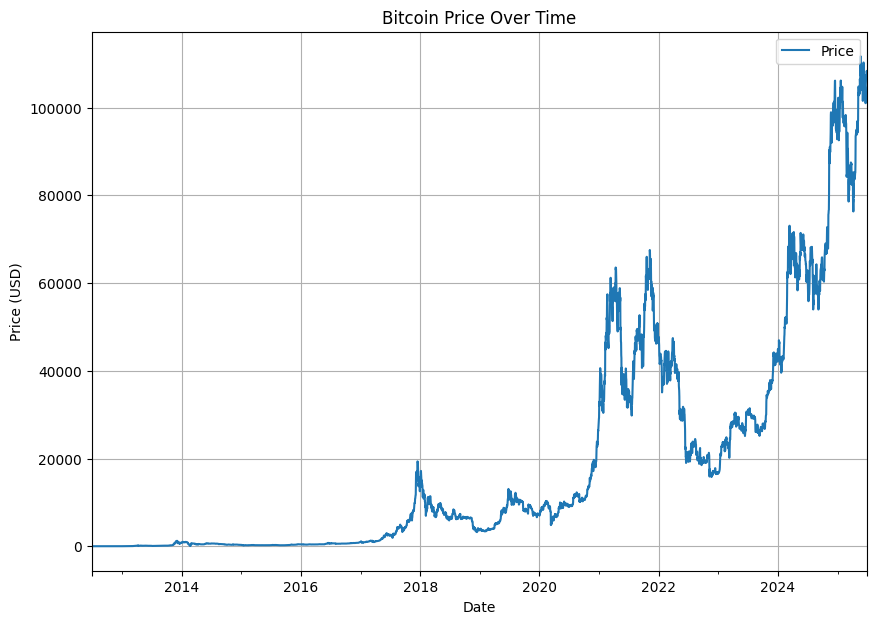

In [9]:
bitcoin_prices["Price"] = bitcoin_prices["Price"].str.replace(',', '').astype(float)
import matplotlib.pyplot as plt
bitcoin_prices.plot(figsize=(10, 7))
plt.title("Bitcoin Price Over Time")
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.grid(True)
plt.show()


In [10]:
import csv
from datetime import datetime
timesteps=[]
btc_price=[]
with open("/content/Bitcoin Historical Data.csv","r")as f:
  csv_render=csv.reader(f,delimiter=",")
  next(csv_render)
  for line in csv_render:
    timesteps.append(datetime.strptime(line[0],"%d/%m/%Y"))
    btc_price.append(float(line[1].replace(",", "")))
timesteps[:10],btc_price[:10]

([datetime.datetime(2012, 6, 30, 0, 0),
  datetime.datetime(2012, 7, 1, 0, 0),
  datetime.datetime(2012, 7, 2, 0, 0),
  datetime.datetime(2012, 7, 3, 0, 0),
  datetime.datetime(2012, 7, 4, 0, 0),
  datetime.datetime(2012, 7, 5, 0, 0),
  datetime.datetime(2012, 7, 6, 0, 0),
  datetime.datetime(2012, 7, 7, 0, 0),
  datetime.datetime(2012, 7, 8, 0, 0),
  datetime.datetime(2012, 7, 9, 0, 0)],
 [6.7, 6.6, 6.8, 6.4, 6.5, 6.7, 6.7, 6.8, 6.8, 7.0])

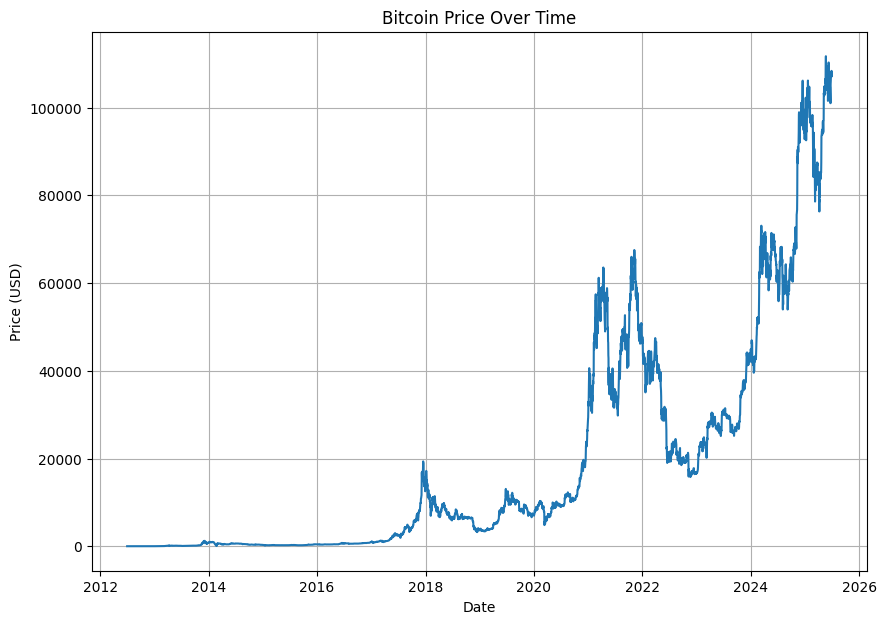

In [11]:
import numpy as np
plt.figure(figsize=(10,7))
plt.plot(timesteps,btc_price)
plt.title("Bitcoin Price Over Time")
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.grid(True)
plt.show()


In [12]:
timesteps=bitcoin_prices.index.to_numpy()
prices=bitcoin_prices["Price"].to_numpy()

In [13]:
timesteps[:10],prices[:10]

(array(['2012-06-30T00:00:00.000000000', '2012-07-01T00:00:00.000000000',
        '2012-07-02T00:00:00.000000000', '2012-07-03T00:00:00.000000000',
        '2012-07-04T00:00:00.000000000', '2012-07-05T00:00:00.000000000',
        '2012-07-06T00:00:00.000000000', '2012-07-07T00:00:00.000000000',
        '2012-07-08T00:00:00.000000000', '2012-07-09T00:00:00.000000000'],
       dtype='datetime64[ns]'),
 array([6.7, 6.6, 6.8, 6.4, 6.5, 6.7, 6.7, 6.8, 6.8, 7. ]))

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(timesteps, prices, test_size=0.2, random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_train.shape

((3799,), (950,), (3799,), (3799,))

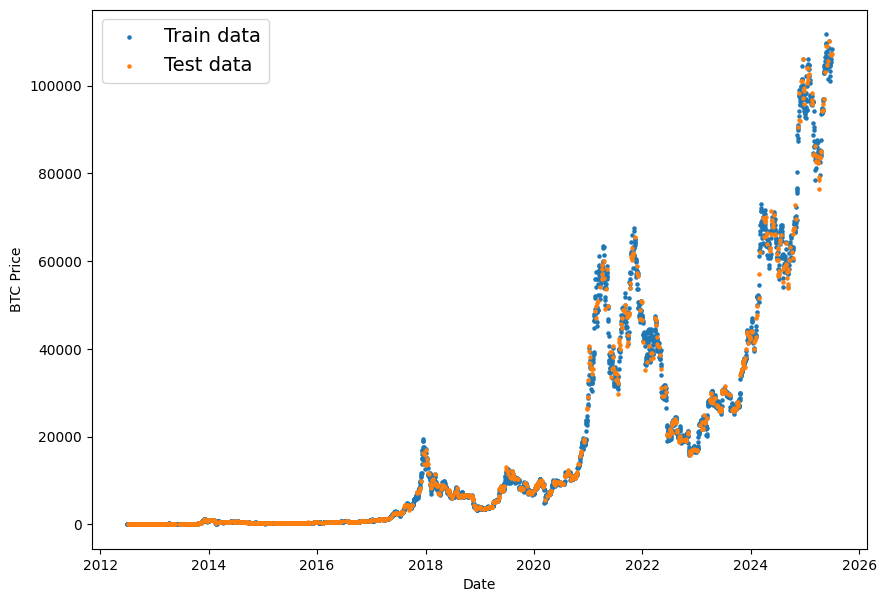

In [15]:
plt.figure(figsize=(10, 7))
plt.scatter(X_train, y_train, s=5, label="Train data")
plt.scatter(X_test, y_test, s=5, label="Test data")
plt.xlabel("Date")
plt.ylabel("BTC Price")
plt.legend(fontsize=14)
plt.show();

In [16]:
split_size = int(0.8 * len(prices))
X_train, y_train = timesteps[:split_size], prices[:split_size]
X_test, y_test = timesteps[split_size:], prices[split_size:]
len(X_train), len(X_test), len(y_train), len(y_test)

(3799, 950, 3799, 950)

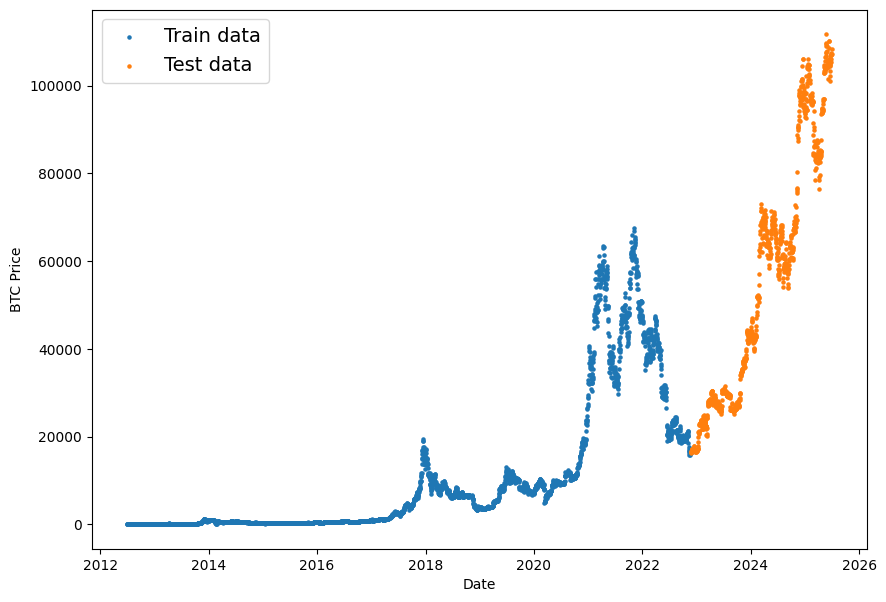

In [17]:
plt.figure(figsize=(10,7))
plt.scatter(X_train, y_train, s=5, label="Train data")
plt.scatter(X_test, y_test, s=5, label="Test data")
plt.xlabel("Date")
plt.ylabel("BTC Price")
plt.legend(fontsize=14)
plt.show();

In [18]:
def plot_time_series(timesteps, values, format=".", start=0, end=None, label=None):
  """
  Plots timesteps (a series of points in time) against values (a series of values across timesteps).

  Parameters
  ----------
  timesteps : array of timestep values
  values : array of values across time
  format : style of plot, default "."
  start : where to start the plot (setting a value will index from start of timesteps & values)
  end : where to end the plot (similar to start but for the end)
  label : label to show on plot about values, default None
  """
  plt.plot(timesteps[start:end], values[start:end], format, label=label)
  plt.xlabel("Time")
  plt.ylabel("BTC Price")
  if label:
    plt.legend(fontsize=14)
  plt.grid(True)

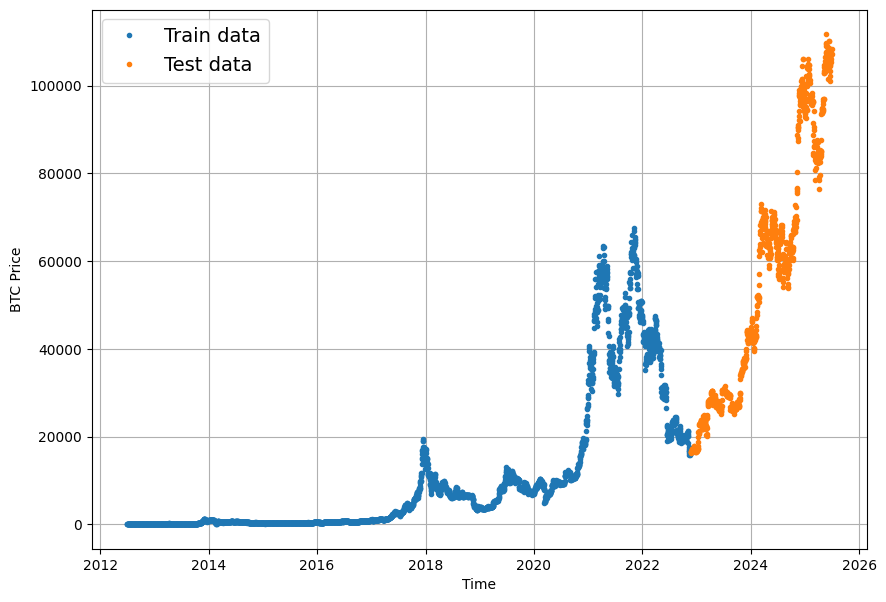

In [19]:
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=X_train, values=y_train, label="Train data")
plot_time_series(timesteps=X_test, values=y_test, label="Test data")

## Modelling Experiments

We've got some Bitcoin historical data, to model it, let's run a series of modelling experiments and see which model performs best.

Terms to be familiar with:
* **Horizon** = number of timesteps into the future we're going to predict
* **Window size** = number of timesteps we're going to use to predict **horizon**

Modelling experiments we're running:
* 0	Naïve model (baseline)
* 1	Dense model, horizon = 1, window = 7
* 2	Same as 1, 	horizon = 1, window = 30
* 3	Same as 1, 	horizon = 7, window =	30
* 4	Conv1D
* 5	LSTM
* 6	Same as 1 (but with multivariate data)
* 7	N-BEATs Algorithm
* 8	Ensemble (multiple models optimized on different loss functions)
* 9	Future prediction model (model to predict future values)
* 10	Same as 1 (but with turkey 🦃 data introduced)


## Model 0: Naive forecast (baseline)

The formula looks like this:

$$\hat{y}_{t} = y_{t-1}$$

In English:

> The prediction at timestep t (y-hat) is equal to the value at timestep t-1 (previous timestep) - this is for a horizon of 1.


In [20]:
navie_forecast=y_test[:-1]
navie_forecast[:10],navie_forecast[-10:]

(array([16601.2, 16512.3, 16456.5, 16425.6, 16211.7, 16440.4, 17163.9,
        16972. , 17093.6, 16884.5]),
 array([103280.5, 102113.2, 100990.4, 105376.9, 106078.6, 107349.4,
        106945.9, 107044.2, 107304.4, 108361.1]))

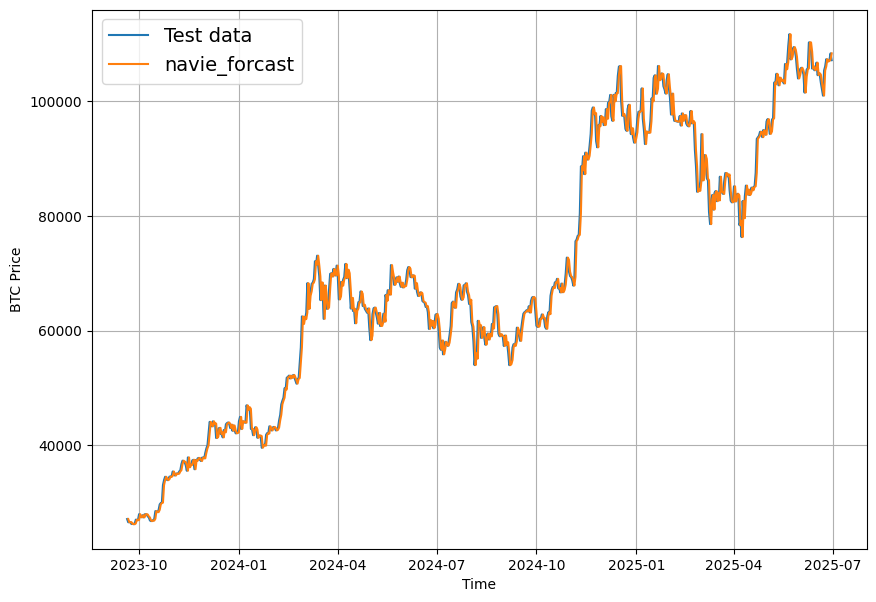

In [21]:
plt.figure(figsize=(10,7))
plot_time_series(timesteps=X_test,values=y_test,start=300,format="-",label="Test data")
plot_time_series(timesteps=X_test[1:],values=navie_forecast,start=300,format="-", label="navie_forcast")

## Evaluating a time series model

Let's look into some evaluation metrics for time series forecasting.

What are we doing?

We're predicting a number, so that means we have a form of a regression problem.

Because we're working on a regression problem, we'll need some regression-like metrics.

A few common regression metrics (which can also be used for time series forecasting):
* MAE - mean absolute error
* MSE - mean squared error
* RMSE - root mean square error
* MAPE/sMAPE - (symmetric) mean absolute percentage error
* MASE - mean absolute scaled error

For all of the above metrics, **lower is better**, for example, an MAE of 0 that is better than an MAE of 100.

The main thing we're evaluating here is: **how do our model's forecasts (y_pred) compare against the actual values (y_true or ground truth values)?**

In [22]:
import tensorflow as tf


In [23]:
def mean_absolute_scaled_error(y_true, y_pred):
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    mae_naive_no_season = tf.reduce_mean(tf.abs(y_true[1:] - y_true[:-1]))
    return mae / mae_naive_no_season


In [24]:
mean_absolute_scaled_error(y_test[1:],navie_forecast).numpy()

np.float64(0.9990406404332934)

In [25]:
def evaluate_preds(y_true, y_pred):
    y_true = tf.cast(y_true, dtype=tf.float32)
    y_pred = tf.cast(y_pred, dtype=tf.float32)

    mae = tf.keras.metrics.MeanAbsoluteError()(y_true, y_pred)
    mse = tf.keras.metrics.MeanSquaredError()(y_true, y_pred)
    rmse = tf.sqrt(mse)
    mape = tf.keras.metrics.MeanAbsolutePercentageError()(y_true, y_pred)
    mase = mean_absolute_scaled_error(y_true, y_pred)

    return {
        "mae": mae.numpy(),
        "mse": mse.numpy(),
        "rmse": rmse.numpy(),
        "mape": mape.numpy(),
        "mase": mase.numpy()
    }

In [26]:
navie_results=evaluate_preds(y_test[1:],navie_forecast)
navie_results

{'mae': np.float32(991.59235),
 'mse': np.float32(2445224.0),
 'rmse': np.float32(1563.7212),
 'mape': np.float32(1.726922),
 'mase': np.float32(0.99904066)}

In [27]:
y_train

array([6.70000e+00, 6.60000e+00, 6.80000e+00, ..., 1.57762e+04,
       1.62129e+04, 1.66239e+04])

In [28]:
WINDOW_SIZE=7
HORIZON=1

In [29]:
def get_labelled_windows(x, horizon=1):
    return x[:, :-horizon], x[:, -horizon:]

In [30]:
test_window,test_label=get_labelled_windows(tf.expand_dims(tf.range(8),axis=0))
test_window,test_label

(<tf.Tensor: shape=(1, 7), dtype=int32, numpy=array([[0, 1, 2, 3, 4, 5, 6]], dtype=int32)>,
 <tf.Tensor: shape=(1, 1), dtype=int32, numpy=array([[7]], dtype=int32)>)

In [31]:
btc_price

[6.7,
 6.6,
 6.8,
 6.4,
 6.5,
 6.7,
 6.7,
 6.8,
 6.8,
 7.0,
 7.2,
 7.2,
 7.8,
 7.7,
 7.5,
 7.6,
 8.5,
 8.8,
 9.1,
 8.9,
 8.5,
 8.9,
 8.4,
 8.4,
 8.6,
 8.8,
 8.9,
 8.9,
 8.9,
 8.7,
 9.1,
 9.4,
 9.6,
 10.5,
 11.0,
 11.0,
 10.9,
 10.9,
 11.1,
 11.1,
 11.1,
 11.4,
 11.5,
 11.6,
 12.0,
 12.2,
 13.3,
 13.5,
 11.6,
 11.6,
 8.0,
 10.1,
 9.9,
 9.8,
 10.1,
 10.6,
 10.5,
 10.6,
 10.9,
 10.9,
 10.9,
 10.8,
 10.2,
 10.0,
 10.2,
 10.5,
 10.4,
 11.0,
 11.2,
 11.0,
 11.0,
 11.0,
 11.2,
 11.3,
 11.4,
 11.4,
 11.7,
 11.8,
 11.9,
 11.9,
 12.3,
 12.6,
 12.3,
 12.4,
 12.2,
 12.2,
 12.1,
 12.2,
 12.3,
 12.3,
 12.4,
 12.4,
 12.4,
 12.4,
 12.8,
 12.9,
 12.9,
 12.7,
 12.5,
 11.8,
 11.8,
 11.9,
 12.1,
 12.0,
 12.0,
 11.9,
 11.7,
 11.8,
 11.9,
 11.8,
 11.9,
 11.7,
 11.7,
 11.6,
 11.7,
 11.6,
 11.6,
 10.9,
 10.2,
 10.3,
 10.7,
 10.6,
 10.9,
 11.2,
 10.6,
 10.5,
 10.6,
 10.8,
 10.8,
 10.9,
 10.9,
 10.9,
 10.8,
 10.9,
 10.9,
 11.0,
 10.9,
 10.9,
 11.2,
 11.8,
 11.8,
 11.6,
 11.8,
 11.7,
 11.8,
 12.4,
 12.4,
 12.4,


In [32]:
import numpy as np


def make_windows(x, window_size=WINDOW_SIZE, horizon=HORIZON):
    """
    Makes windowed dataset in chronological order,
    where label is the value before the window.
    """
    window_step = np.expand_dims(np.arange(window_size+horizon), axis=0)
    window_indexes = window_step + np.expand_dims(np.arange(len(x)-(window_size+horizon-1)), axis=0).T
    windowed_array = x[window_indexes]
    windows, labels = get_labelled_windows(windowed_array, horizon=horizon)
    return windows, labels

In [33]:
full_windows,full_labels=make_windows(prices,window_size=WINDOW_SIZE,horizon=HORIZON)
len(full_windows),len(full_labels)

(4742, 4742)

In [34]:
for i in range(3):
    print(f"Window: {full_windows[i-3]} -> Label: {full_labels[i-3]}")

Window: [102113.2 100990.4 105376.9 106078.6 107349.4 106945.9 107044.2] -> Label: [107304.4]
Window: [100990.4 105376.9 106078.6 107349.4 106945.9 107044.2 107304.4] -> Label: [108361.1]
Window: [105376.9 106078.6 107349.4 106945.9 107044.2 107304.4 108361.1] -> Label: [107171.1]


In [35]:
def make_train_test_splits(windows, labels, test_split=0.2):
    """
    Splits matching pairs of windows and labels into train and test splits
    without shuffling (preserving time order).

    Args:
        windows (np.ndarray): Array of input windows.
        labels (np.ndarray): Array of corresponding labels.
        test_split (float): Proportion of data to use for testing (default 0.2 = 20%).

    Returns:
        Tuple: train_windows, test_windows, train_labels, test_labels
    """
    split_size = int(len(windows) * (1 - test_split))

    train_windows = windows[:split_size]
    train_labels = labels[:split_size]

    test_windows = windows[split_size:]
    test_labels = labels[split_size:]

    print(f"Train size: {len(train_windows)}, Test size: {len(test_windows)}")
    return train_windows, test_windows, train_labels, test_labels


In [36]:
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(full_windows, full_labels,test_split=0.2)
len(train_windows), len(test_windows), len(train_labels), len(test_labels)

Train size: 3793, Test size: 949


(3793, 949, 3793, 949)

In [37]:
train_windows[:5], train_labels[:5]

(array([[6.7, 6.6, 6.8, 6.4, 6.5, 6.7, 6.7],
        [6.6, 6.8, 6.4, 6.5, 6.7, 6.7, 6.8],
        [6.8, 6.4, 6.5, 6.7, 6.7, 6.8, 6.8],
        [6.4, 6.5, 6.7, 6.7, 6.8, 6.8, 7. ],
        [6.5, 6.7, 6.7, 6.8, 6.8, 7. , 7.2]]),
 array([[6.8],
        [6.8],
        [7. ],
        [7.2],
        [7.2]]))

In [38]:
import os

def create_model_checkpoint(model_name,save_path="model_experiment"):
  os.makedirs(save_path, exist_ok=True)
  checkpoint_path = os.path.join(save_path, model_name)
  return tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                            monitor="val_loss",
                                            verbose=0,
                                            save_best_only=True
                                            )

## Model 1: Dense model (window = 7, horizon = 1)

Our first deep model is going to be a simple dense model:
* A single dense layer with 128 hidden units and ReLU
* An output layer with linear activation (no activation)
* Adam optimizaiton and MAE loss function
* Batch size of 128 (previously we've used 32)
* 100 epochs

Why these values?

I picked them out of experimentation.

* **Hyperparameters** = values a machine learning practitioner (you!) can adjust themselves
* **Parameters** = values a model learns on its own

In [39]:
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

model1=tf.keras.Sequential([
    layers.Dense(128,activation="relu"),
    layers.Dense(HORIZON,activation="linear")
],name="model1_Dense")

model1.compile(loss="mae",
               optimizer="Adam",
               metrics=["mae","mse"])

model1.fit(x=train_windows,
           y=train_labels,
           epochs=100,
           verbose=1,
           batch_size=128,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model1.name+ ".keras")]
           )

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 6186.8735 - mae: 6186.8735 - mse: 172528992.0000 - val_loss: 4030.8193 - val_mae: 4030.8193 - val_mse: 24535698.0000
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 628.4171 - mae: 628.4171 - mse: 1967065.7500 - val_loss: 1650.8673 - val_mae: 1650.8673 - val_mse: 5792279.5000
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 467.7261 - mae: 467.7261 - mse: 1154431.7500 - val_loss: 1517.4399 - val_mae: 1517.4399 - val_mse: 4842960.5000
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 451.9099 - mae: 451.9099 - mse: 1063504.8750 - val_loss: 1454.6093 - val_mae: 1454.6093 - val_mse: 4605336.0000
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 429.5641 - mae: 429.5641 - mse: 974539.3125 - val_loss: 1372.1472 - val_mae: 1372.1472 - val_mse: 4145910.5000
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 416.1190 - mae: 416.1190 - mse: 909678.4375 - val_loss: 1320.0593 - val_mae: 1320

In [40]:

model1.evaluate(test_windows, test_labels)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 679.9125 - mae: 679.9125 - mse: 1188075.8750


[1094.8179931640625, 1094.8179931640625, 2691331.25]

In [41]:
model1=tf.keras.models.load_model("model_experiment/model1_Dense.keras")
model1.evaluate(test_window,test_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - loss: 0.4024 - mae: 0.4024 - mse: 0.1619


[0.40236759185791016, 0.40236759185791016, 0.16189968585968018]

In [42]:
def make_preds(model,input_data):
  forecast=model.predict(input_data)
  return tf.squeeze(forecast)


In [43]:
model1_preds=make_preds(model1,test_windows)
len(model1_preds),model1_preds[:10]

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


(949,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([16602.578, 16539.99 , 16490.832, 16438.674, 16236.723, 16429.654,
        17116.566, 17003.002, 17092.85 , 16937.477], dtype=float32)>)

In [44]:
tf.squeeze(test_labels).shape, model1_preds.shape

(TensorShape([949]), TensorShape([949]))

In [45]:
test_windows[:1]

array([[16638.3, 16699.2, 16286.7, 15776.2, 16212.9, 16623.9, 16601.2]])

In [46]:
test_labels[:1]

array([[16512.3]])

In [47]:
model1_results=evaluate_preds(y_true=test_label,y_pred=model1_preds)
model1_results

{'mae': np.float32(55449.23),
 'mse': np.float32(3873351200.0),
 'rmse': np.float32(62236.25),
 'mape': np.float32(792131.94),
 'mase': np.float32(nan)}

In [48]:
navie_results

{'mae': np.float32(991.59235),
 'mse': np.float32(2445224.0),
 'rmse': np.float32(1563.7212),
 'mape': np.float32(1.726922),
 'mase': np.float32(0.99904066)}

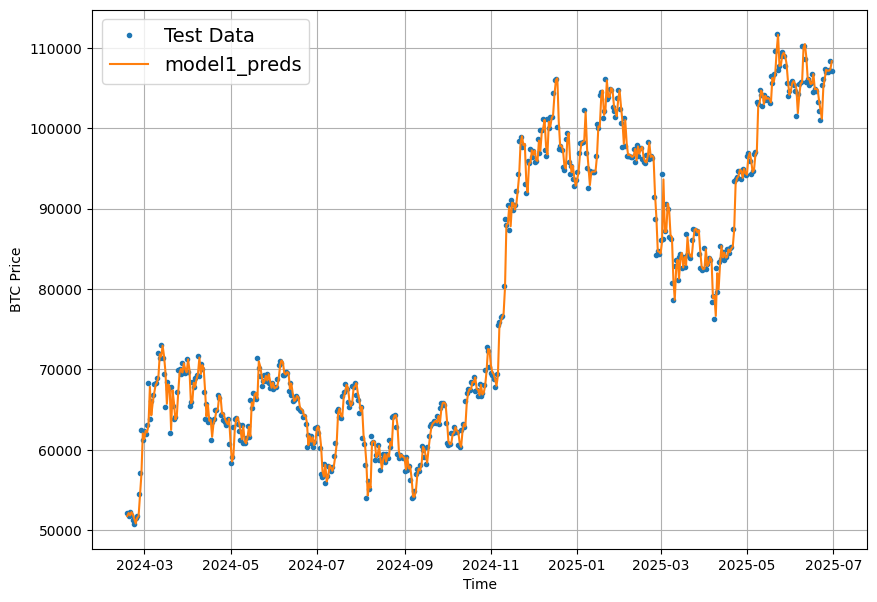

In [49]:
offset = 450
plt.figure(figsize=(10, 7))

plot_time_series(
    timesteps=X_test[-len(test_windows):],
    values=test_labels,
    start=offset,
    label="Test Data"
)

plot_time_series(
    timesteps=X_test[-len(test_windows):],
    values=model1_preds,
    start=offset,
    format="-",
    label="model1_preds"
)


## Model 2: Dense (window = 30, horizon = 1)

In [50]:
WINDOW_SIZE=30
HORIZON=1

In [51]:
full_windows,full_labels=make_windows(prices,window_size=WINDOW_SIZE,horizon=HORIZON)
len(full_windows),len(full_labels)

(4719, 4719)

In [52]:
train_windows,test_windows,train_labels,test_labels=make_train_test_splits(full_windows,full_labels,test_split=0.2)
len(train_windows), len(test_windows), len(train_labels), len(test_labels)

Train size: 3775, Test size: 944


(3775, 944, 3775, 944)

In [53]:
train_windows[:3], train_labels[:3]

(array([[6.7, 6.6, 6.8, 6.4, 6.5, 6.7, 6.7, 6.8, 6.8, 7. , 7.2, 7.2, 7.8,
         7.7, 7.5, 7.6, 8.5, 8.8, 9.1, 8.9, 8.5, 8.9, 8.4, 8.4, 8.6, 8.8,
         8.9, 8.9, 8.9, 8.7],
        [6.6, 6.8, 6.4, 6.5, 6.7, 6.7, 6.8, 6.8, 7. , 7.2, 7.2, 7.8, 7.7,
         7.5, 7.6, 8.5, 8.8, 9.1, 8.9, 8.5, 8.9, 8.4, 8.4, 8.6, 8.8, 8.9,
         8.9, 8.9, 8.7, 9.1],
        [6.8, 6.4, 6.5, 6.7, 6.7, 6.8, 6.8, 7. , 7.2, 7.2, 7.8, 7.7, 7.5,
         7.6, 8.5, 8.8, 9.1, 8.9, 8.5, 8.9, 8.4, 8.4, 8.6, 8.8, 8.9, 8.9,
         8.9, 8.7, 9.1, 9.4]]),
 array([[9.1],
        [9.4],
        [9.6]]))

In [54]:
model2=tf.keras.Sequential([
    layers.Dense(128,activation="relu"),
    layers.Dense(HORIZON,activation="linear")
],name="model2_Dense")

model2.compile(loss="mae",
               optimizer="Adam",
               metrics=["mae","mse"])

model2.fit(x=train_windows,
           y=train_labels,
           epochs=100,
           verbose=1,
           batch_size=128,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model2.name+ ".keras")]
           )

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 1180.8770 - mae: 1180.8770 - mse: 6838777.0000 - val_loss: 3105.1248 - val_mae: 3105.1248 - val_mse: 18354640.0000
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 750.2910 - mae: 750.2910 - mse: 3148814.7500 - val_loss: 2126.8850 - val_mae: 2126.8850 - val_mse: 9252475.0000
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 620.1336 - mae: 620.1336 - mse: 2123537.7500 - val_loss: 2351.6409 - val_mae: 2351.6409 - val_mse: 10768115.0000
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 732.0285 - mae: 732.0285 - mse: 2930881.2500 - val_loss: 2033.9885 - val_mae: 2033.9885 - val_mse: 8116986.5000
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 589.3174 - mae: 589.3174 - mse: 1912450.5000 - val_loss: 1956.7739 - val_mae: 1956.7739 - val_mse: 7825408.5000
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 660.7141 - mae: 660.7141 - mse: 2387685.2500 - val_loss: 1747.2985 - val_mae: 174

In [55]:
model2=tf.keras.models.load_model("model_experiment/model2_Dense.keras")
model2.evaluate(test_windows, test_labels)

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 708.0787 - mae: 708.0787 - mse: 1341575.1250


[1154.451171875, 1154.451171875, 3065026.0]

In [56]:
model2_preds=make_preds(model2,test_windows)
len(model2_preds),model2_preds[:10]

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


(944,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([16312.029, 16707.152, 17069.754, 16811.105, 16698.373, 16725.254,
        16494.05 , 16925.48 , 16833.717, 16864.426], dtype=float32)>)

In [57]:
tf.squeeze(test_labels).shape, model2_preds.shape

(TensorShape([944]), TensorShape([944]))

In [58]:
model2_results=evaluate_preds(y_true=test_label,y_pred=model2_preds)
model2_results

{'mae': np.float32(55445.28),
 'mse': np.float32(3864235500.0),
 'rmse': np.float32(62162.973),
 'mape': np.float32(792075.3),
 'mase': np.float32(nan)}

In [59]:
model1_results

{'mae': np.float32(55449.23),
 'mse': np.float32(3873351200.0),
 'rmse': np.float32(62236.25),
 'mape': np.float32(792131.94),
 'mase': np.float32(nan)}

In [60]:
navie_results

{'mae': np.float32(991.59235),
 'mse': np.float32(2445224.0),
 'rmse': np.float32(1563.7212),
 'mape': np.float32(1.726922),
 'mase': np.float32(0.99904066)}

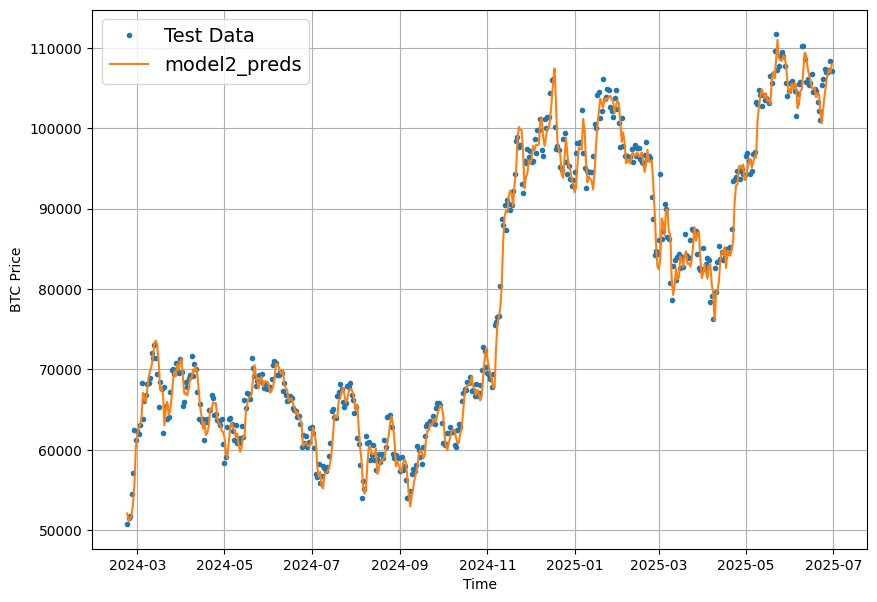

In [61]:
offset = 450
plt.figure(figsize=(10, 7))

plot_time_series(
    timesteps=X_test[-len(test_windows):],
    values=test_labels,
    start=offset,
    label="Test Data"
)

plot_time_series(
    timesteps=X_test[-len(test_windows):],
    values=model2_preds,
    start=offset,
    format="-",
    label="model2_preds"
)

In [62]:
def evaluate_preds(y_true, y_pred):
    y_true = tf.cast(y_true, dtype=tf.float32)
    y_pred = tf.cast(y_pred, dtype=tf.float32)

    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    rmse = tf.sqrt(mse)
    mape = tf.reduce_mean(tf.abs((y_true - y_pred) / y_true)) * 100
    mase = mean_absolute_scaled_error(y_true, y_pred)

    return {
        "mae": mae.numpy(),
        "mse": mse.numpy(),
        "rmse": rmse.numpy(),
        "mape": mape.numpy(),
        "mase": mase.numpy()
    }


## Model 3: Dense (window = 30, horizon = 7)



In [63]:
WINDOW_SIZE = 30
HORIZON = 7

full_windows, full_labels = make_windows(prices, window_size=WINDOW_SIZE, horizon=HORIZON)


In [64]:
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(full_windows, full_labels,test_split=0.2)

Train size: 3770, Test size: 943


In [65]:
train_windows[:3], train_labels[:3]

(array([[6.7, 6.6, 6.8, 6.4, 6.5, 6.7, 6.7, 6.8, 6.8, 7. , 7.2, 7.2, 7.8,
         7.7, 7.5, 7.6, 8.5, 8.8, 9.1, 8.9, 8.5, 8.9, 8.4, 8.4, 8.6, 8.8,
         8.9, 8.9, 8.9, 8.7],
        [6.6, 6.8, 6.4, 6.5, 6.7, 6.7, 6.8, 6.8, 7. , 7.2, 7.2, 7.8, 7.7,
         7.5, 7.6, 8.5, 8.8, 9.1, 8.9, 8.5, 8.9, 8.4, 8.4, 8.6, 8.8, 8.9,
         8.9, 8.9, 8.7, 9.1],
        [6.8, 6.4, 6.5, 6.7, 6.7, 6.8, 6.8, 7. , 7.2, 7.2, 7.8, 7.7, 7.5,
         7.6, 8.5, 8.8, 9.1, 8.9, 8.5, 8.9, 8.4, 8.4, 8.6, 8.8, 8.9, 8.9,
         8.9, 8.7, 9.1, 9.4]]),
 array([[ 9.1,  9.4,  9.6, 10.5, 11. , 11. , 10.9],
        [ 9.4,  9.6, 10.5, 11. , 11. , 10.9, 10.9],
        [ 9.6, 10.5, 11. , 11. , 10.9, 10.9, 11.1]]))

In [66]:
btc_price

[6.7,
 6.6,
 6.8,
 6.4,
 6.5,
 6.7,
 6.7,
 6.8,
 6.8,
 7.0,
 7.2,
 7.2,
 7.8,
 7.7,
 7.5,
 7.6,
 8.5,
 8.8,
 9.1,
 8.9,
 8.5,
 8.9,
 8.4,
 8.4,
 8.6,
 8.8,
 8.9,
 8.9,
 8.9,
 8.7,
 9.1,
 9.4,
 9.6,
 10.5,
 11.0,
 11.0,
 10.9,
 10.9,
 11.1,
 11.1,
 11.1,
 11.4,
 11.5,
 11.6,
 12.0,
 12.2,
 13.3,
 13.5,
 11.6,
 11.6,
 8.0,
 10.1,
 9.9,
 9.8,
 10.1,
 10.6,
 10.5,
 10.6,
 10.9,
 10.9,
 10.9,
 10.8,
 10.2,
 10.0,
 10.2,
 10.5,
 10.4,
 11.0,
 11.2,
 11.0,
 11.0,
 11.0,
 11.2,
 11.3,
 11.4,
 11.4,
 11.7,
 11.8,
 11.9,
 11.9,
 12.3,
 12.6,
 12.3,
 12.4,
 12.2,
 12.2,
 12.1,
 12.2,
 12.3,
 12.3,
 12.4,
 12.4,
 12.4,
 12.4,
 12.8,
 12.9,
 12.9,
 12.7,
 12.5,
 11.8,
 11.8,
 11.9,
 12.1,
 12.0,
 12.0,
 11.9,
 11.7,
 11.8,
 11.9,
 11.8,
 11.9,
 11.7,
 11.7,
 11.6,
 11.7,
 11.6,
 11.6,
 10.9,
 10.2,
 10.3,
 10.7,
 10.6,
 10.9,
 11.2,
 10.6,
 10.5,
 10.6,
 10.8,
 10.8,
 10.9,
 10.9,
 10.9,
 10.8,
 10.9,
 10.9,
 11.0,
 10.9,
 10.9,
 11.2,
 11.8,
 11.8,
 11.6,
 11.8,
 11.7,
 11.8,
 12.4,
 12.4,
 12.4,


In [67]:
model3=tf.keras.Sequential([
    layers.Dense(128,activation="relu"),
    layers.Dense(HORIZON)
],name="model3_Dense")

model3.compile(loss="mae",
               optimizer="Adam",
               metrics=["mae","mse"])

model3.fit(x=train_windows,
           y=train_labels,
           epochs=100,
           verbose=1,
           batch_size=128,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model3.name+ ".keras")]
           )

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 5966.5161 - mae: 5966.5161 - mse: 228442912.0000 - val_loss: 6439.6245 - val_mae: 6439.6245 - val_mse: 92512584.0000
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1248.5087 - mae: 1248.5087 - mse: 8404181.0000 - val_loss: 3425.2341 - val_mae: 3425.2341 - val_mse: 24350166.0000
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 955.4352 - mae: 955.4352 - mse: 4860577.5000 - val_loss: 2889.7952 - val_mae: 2889.7954 - val_mse: 16685320.0000
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 854.7836 - mae: 854.7836 - mse: 3982798.5000 - val_loss: 2755.6482 - val_mae: 2755.6484 - val_mse: 15295775.0000
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 805.0266 - mae: 805.0266 - mse: 3547294.5000 - val_loss: 2568.1262 - val_mae: 2568.1262 - val_mse: 13334402.0000
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 768.6088 - mae: 768.6088 - mse: 3262489.7500 - val_loss: 2409.1948 - val_m

In [68]:
model3=tf.keras.models.load_model("model_experiment/model3_Dense.keras")
model3.evaluate(test_windows, test_labels)

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1354.4843 - mae: 1354.4843 - mse: 4628277.5000


[2095.25927734375, 2095.25927734375, 9514718.0]

In [69]:
model3_preds=make_preds(model=model3,input_data=test_windows)
model3_preds.shape

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


TensorShape([943, 7])

In [70]:
test_label.shape

TensorShape([1, 1])

In [71]:
test_labels.shape,model3_preds.shape

((943, 7), TensorShape([943, 7]))

In [72]:
model3_results=evaluate_preds(y_true=test_labels,y_pred=model3_preds)
model3_results

{'mae': np.float32(2095.259),
 'mse': np.float32(9514717.0),
 'rmse': np.float32(3084.5935),
 'mape': np.float32(3.7746706),
 'mase': np.float32(2.1038675)}

In [73]:
model2_results

{'mae': np.float32(55445.28),
 'mse': np.float32(3864235500.0),
 'rmse': np.float32(62162.973),
 'mape': np.float32(792075.3),
 'mase': np.float32(nan)}

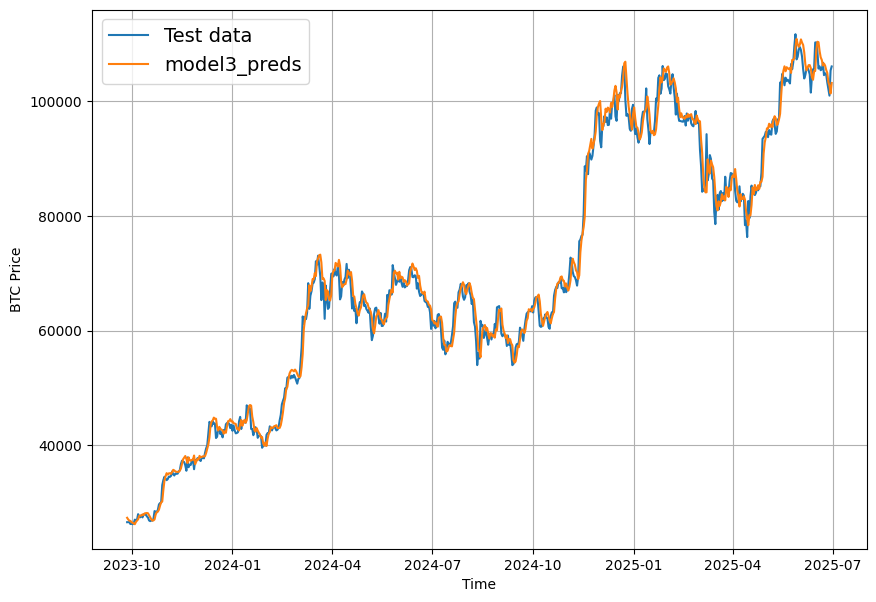

In [74]:
offset = 300
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=X_test[-len(test_windows):],
                 values=test_labels[:, 0],
                 start=offset,
                 format="-",
                 label="Test data")
plot_time_series(timesteps=X_test[-len(test_windows):],
                 values=tf.reduce_mean(model3_preds, axis=1),
                 start=offset,
                 format="-",
                 label="model3_preds")

### 🔍 Model Evaluation - MAE Comparison

The following chart compares the Mean Absolute Error (MAE) for different models used in Bitcoin price prediction. Lower values indicate better performance.


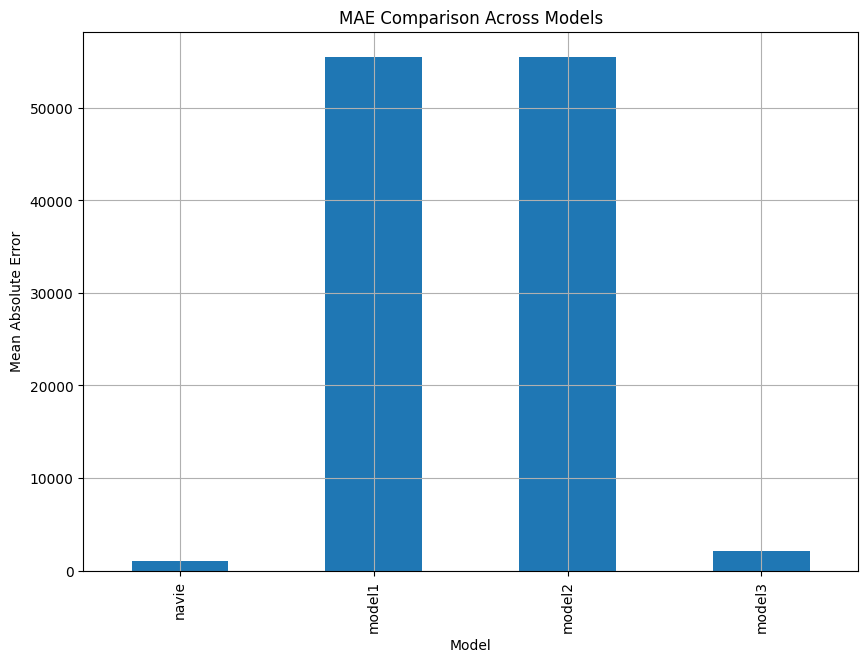

In [75]:
import pandas as pd
import matplotlib.pyplot as plt


results_df = pd.DataFrame({
    "navie": navie_results,
    "model1": model1_results,
    "model2": model2_results,
    "model3": model3_results
}).T

results_df[["mae"]].plot(
    kind="bar",
    figsize=(10, 7),
    legend=False
)
plt.title("MAE Comparison Across Models")
plt.ylabel("Mean Absolute Error")
plt.xlabel("Model")
plt.grid(True)
plt.show()




✅ **Observations:**
- `model1` and `model2` show extremely high MAE, suggesting poor learning or incorrect training setup.
- `navie` (naive baseline) and `model3` perform significantly better, with `model3` showing the best results.
- so we use horizon=7 and window_size=30

## Model 4: Conv1D

In [76]:
from tensorflow import keras
from tensorflow.keras import layers

In [77]:
from tensorflow.keras.layers import Dense,GlobalAvgPool1D,Conv1D
tf.random.set_seed(42)

model4=tf.keras.Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(30, 1)),
    GlobalAvgPool1D(),
    Dense(128,activation="relu"),
    Dense(HORIZON)
],name="model4_Conv1D")

model4.compile(loss="mae",
               optimizer="adam")

model4.fit(train_windows,
           train_labels,
           epochs=100,
           batch_size=128,
           verbose=1,
           validation_data=(test_windows,test_labels),
           callbacks=[create_model_checkpoint(model_name=model4.name +".keras")]
           )

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 9383.4170 - val_loss: 26359.6875
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3654.5732 - val_loss: 6418.8105
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1335.7163 - val_loss: 3979.4050
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1259.1149 - val_loss: 3984.6060
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1252.9819 - val_loss: 3963.4363
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1251.8789 - val_loss: 3947.0144
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1250.9810 - val_loss: 3929.0894
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1250.5404 - val_loss: 3923.7395
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1249.3120 - val_loss: 3898.4426
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1247.6188 - val_loss: 3893.3149
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1245.9713 - val_loss: 3854.6499
Epoch 1

In [78]:
model4=tf.keras.models.load_model("model_experiment/model4_Conv1D.keras")
model4.evaluate(test_windows,test_labels)

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1696.2256


2552.805908203125

In [79]:
model4_preds=make_preds(model=model4,input_data=test_windows)
model4_preds.shape

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


TensorShape([943, 7])

In [80]:
test_labels.shape

(943, 7)

In [81]:
model4_results=evaluate_preds(y_true=test_labels,y_pred=model4_preds)
model4_results

{'mae': np.float32(2552.806),
 'mse': np.float32(12928924.0),
 'rmse': np.float32(3595.6814),
 'mape': np.float32(4.63439),
 'mase': np.float32(2.5632942)}

In [82]:
model3_results

{'mae': np.float32(2095.259),
 'mse': np.float32(9514717.0),
 'rmse': np.float32(3084.5935),
 'mape': np.float32(3.7746706),
 'mase': np.float32(2.1038675)}

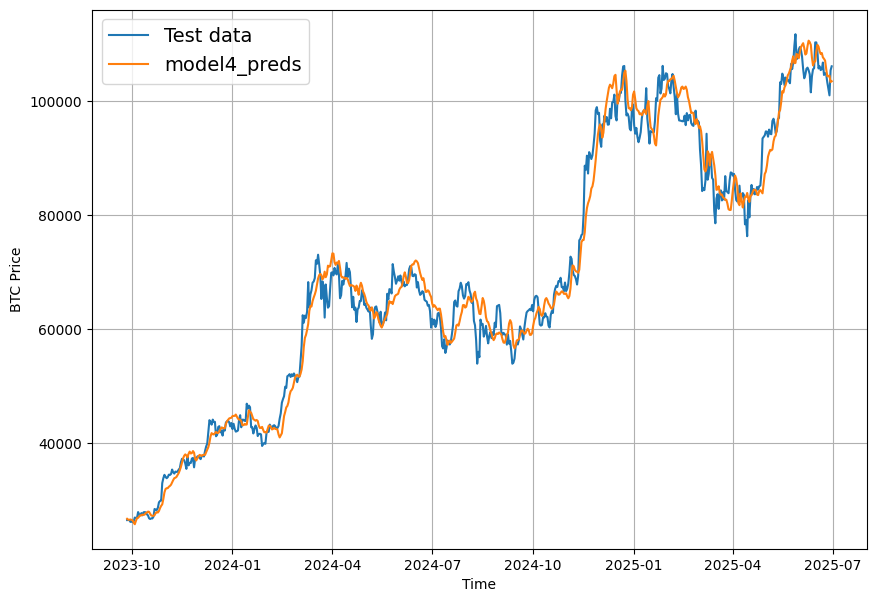

In [83]:
offset = 300
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=X_test[-len(test_windows):],
                 values=test_labels[:, 0],
                 start=offset,
                 format="-",
                 label="Test data")
plot_time_series(timesteps=X_test[-len(test_windows):],
                 values=tf.reduce_mean(model4_preds, axis=1),
                 start=offset,
                 format="-",
                 label="model4_preds")

## Model 5: RNN (LSTM)

In [84]:
WINDOW_SIZE=30
HORIZON=7
full_windows, full_labels = make_windows(prices, window_size=WINDOW_SIZE, horizon=HORIZON)
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(full_windows, full_labels,test_split=0.2)
train_windows[:3], train_labels[:3]

Train size: 3770, Test size: 943


(array([[6.7, 6.6, 6.8, 6.4, 6.5, 6.7, 6.7, 6.8, 6.8, 7. , 7.2, 7.2, 7.8,
         7.7, 7.5, 7.6, 8.5, 8.8, 9.1, 8.9, 8.5, 8.9, 8.4, 8.4, 8.6, 8.8,
         8.9, 8.9, 8.9, 8.7],
        [6.6, 6.8, 6.4, 6.5, 6.7, 6.7, 6.8, 6.8, 7. , 7.2, 7.2, 7.8, 7.7,
         7.5, 7.6, 8.5, 8.8, 9.1, 8.9, 8.5, 8.9, 8.4, 8.4, 8.6, 8.8, 8.9,
         8.9, 8.9, 8.7, 9.1],
        [6.8, 6.4, 6.5, 6.7, 6.7, 6.8, 6.8, 7. , 7.2, 7.2, 7.8, 7.7, 7.5,
         7.6, 8.5, 8.8, 9.1, 8.9, 8.5, 8.9, 8.4, 8.4, 8.6, 8.8, 8.9, 8.9,
         8.9, 8.7, 9.1, 9.4]]),
 array([[ 9.1,  9.4,  9.6, 10.5, 11. , 11. , 10.9],
        [ 9.4,  9.6, 10.5, 11. , 11. , 10.9, 10.9],
        [ 9.6, 10.5, 11. , 11. , 10.9, 10.9, 11.1]]))

In [85]:
tf.random.set_seed(42)
inputs=layers.Input(shape=(WINDOW_SIZE,1),name="input_layer")
x=layers.LSTM(64,activation="relu",return_sequences=False,name="LSTM_layer")(inputs)
x=Dense(32,activation="relu",name="dense_layer_1")(x)
outputs=Dense(HORIZON,name="output_layer")(x)
model5=tf.keras.Model(inputs=inputs,outputs=outputs,name="model5_LSTM")

model5.compile(loss="mae",
               optimizer="adam")

model5.fit(train_windows,
           train_labels,
           epochs=100,
           batch_size=128,
           verbose=1,
           validation_data=(test_windows,test_labels),
           callbacks=[create_model_checkpoint(model_name=model5.name +".keras")]
           )

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 11097.6963 - val_loss: 50834.9922
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 8470.0498 - val_loss: 30910.3906
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5319.0127 - val_loss: 21525.8945
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4317.7837 - val_loss: 19433.0020
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5912.7856 - val_loss: 28626.8125
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3791.8911 - val_loss: 12683.0723
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2290.7764 - val_loss: 22366.1777
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3809.5688 - val_loss: 15155.8232
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2195.2427 - val_loss: 5548.6743
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1567.7654 - val_loss: 8856.1152
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2979.4729 - val_lo

In [86]:
model5=tf.keras.models.load_model("/content/model_experiment/model5_LSTM.keras")
model5.evaluate(test_windows,test_labels)

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1693.4861


2530.045166015625

In [87]:
model5_preds=make_preds(model=model5,input_data=test_windows)
model5_preds.shape

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


TensorShape([943, 7])

In [88]:
test_labels.shape

(943, 7)

In [89]:
model5_results=evaluate_preds(y_true=test_labels,y_pred=model5_preds)
model5_results

{'mae': np.float32(2530.0447),
 'mse': np.float32(12993487.0),
 'rmse': np.float32(3604.648),
 'mape': np.float32(4.6144648),
 'mase': np.float32(2.5404394)}

In [90]:
model4_results

{'mae': np.float32(2552.806),
 'mse': np.float32(12928924.0),
 'rmse': np.float32(3595.6814),
 'mape': np.float32(4.63439),
 'mase': np.float32(2.5632942)}

In [91]:
model3_results

{'mae': np.float32(2095.259),
 'mse': np.float32(9514717.0),
 'rmse': np.float32(3084.5935),
 'mape': np.float32(3.7746706),
 'mase': np.float32(2.1038675)}

In [92]:
bitcoin_prices

,Price
Date,
2012-06-30,6.7
2012-07-01,6.6
2012-07-02,6.8
2012-07-03,6.4
2012-07-04,6.5
...,...
2025-06-26,106945.9
2025-06-27,107044.2
2025-06-28,107304.4


## Model 6: Dense (multivariate time series)

In [93]:
bitcoin_prices_block = bitcoin_prices.copy()
bitcoin_prices_block["block_reward"] = None

block_reward_1 = 25
block_reward_2 = 12.5
block_reward_3 = 6.25
block_reward_4 = 3.125


block_reward_1_datetime = np.datetime64("2012-11-28")
block_reward_2_datetime = np.datetime64("2016-07-09")
block_reward_3_datetime = np.datetime64("2020-05-11")
block_reward_4_datetime = np.datetime64("2024-04-20")


In [94]:
start_idx = bitcoin_prices.index[0]

reward_2_days = (block_reward_2_datetime - start_idx).days
reward_3_days = (block_reward_3_datetime - start_idx).days
reward_4_days = (block_reward_4_datetime - start_idx).days


In [95]:
bitcoin_prices_block.iloc[:reward_2_days, bitcoin_prices_block.columns.get_loc("block_reward")] = block_reward_1
bitcoin_prices_block.iloc[reward_2_days:reward_3_days, bitcoin_prices_block.columns.get_loc("block_reward")] = block_reward_2
bitcoin_prices_block.iloc[reward_3_days:reward_4_days, bitcoin_prices_block.columns.get_loc("block_reward")] = block_reward_3
bitcoin_prices_block.iloc[reward_4_days:, bitcoin_prices_block.columns.get_loc("block_reward")] = block_reward_4


In [96]:
from sklearn.preprocessing import minmax_scale

In [97]:
scaled_price_block_df = pd.DataFrame(
    minmax_scale(bitcoin_prices_block[["Price", "block_reward"]]),
    columns=["Price", "block_reward"],
    index=bitcoin_prices_block.index
)

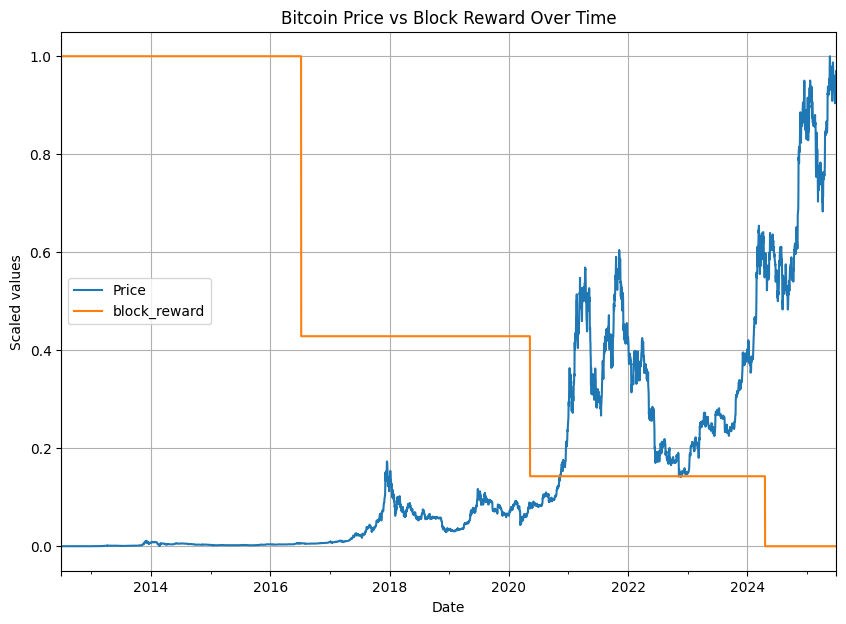

In [98]:
scaled_price_block_df.plot(figsize=(10, 7), title="Bitcoin Price vs Block Reward Over Time")
plt.ylabel("Scaled values")
plt.grid(True)
plt.show()

In [99]:
bitcoin_prices_block.head()

,Price,block_reward
Date,,
2012-06-30,6.7,25
2012-07-01,6.6,25
2012-07-02,6.8,25
2012-07-03,6.4,25
2012-07-04,6.5,25


In [100]:
HORIZON=1
WINDOW_SIZE=7

In [101]:
bitcoin_prices_windowed=bitcoin_prices_block.copy()

for i in range(WINDOW_SIZE):
 bitcoin_prices_windowed[f"Prince+{i+1}"]=bitcoin_prices_windowed["Price"].shift(periods=i+1)

bitcoin_prices_windowed.head(10)


,Price,block_reward,Prince+1,Prince+2,Prince+3,Prince+4,Prince+5,Prince+6,Prince+7
Date,,,,,,,,,
2012-06-30,6.7,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-07-01,6.6,25,6.7,NaN,NaN,NaN,NaN,NaN,NaN
2012-07-02,6.8,25,6.6,6.7,NaN,NaN,NaN,NaN,NaN
2012-07-03,6.4,25,6.8,6.6,6.7,NaN,NaN,NaN,NaN
2012-07-04,6.5,25,6.4,6.8,6.6,6.7,NaN,NaN,NaN
2012-07-05,6.7,25,6.5,6.4,6.8,6.6,6.7,NaN,NaN
2012-07-06,6.7,25,6.7,6.5,6.4,6.8,6.6,6.7,NaN
2012-07-07,6.8,25,6.7,6.7,6.5,6.4,6.8,6.6,6.7
2012-07-08,6.8,25,6.8,6.7,6.7,6.5,6.4,6.8,6.6


In [102]:
bitcoin_prices_windowed.tail()

,Price,block_reward,Prince+1,Prince+2,Prince+3,Prince+4,Prince+5,Prince+6,Prince+7
Date,,,,,,,,,
2025-06-26,106945.9,3.125,107349.4,106078.6,105376.9,100990.4,102113.2,103280.5,104669.6
2025-06-27,107044.2,3.125,106945.9,107349.4,106078.6,105376.9,100990.4,102113.2,103280.5
2025-06-28,107304.4,3.125,107044.2,106945.9,107349.4,106078.6,105376.9,100990.4,102113.2
2025-06-29,108361.1,3.125,107304.4,107044.2,106945.9,107349.4,106078.6,105376.9,100990.4
2025-06-30,107171.1,3.125,108361.1,107304.4,107044.2,106945.9,107349.4,106078.6,105376.9


In [103]:
X=bitcoin_prices_windowed.dropna().drop("Price",axis=1).astype(np.float32)
y=bitcoin_prices_windowed.dropna()["Price"].astype(np.float32)
X.head()

,block_reward,Prince+1,Prince+2,Prince+3,Prince+4,Prince+5,Prince+6,Prince+7
Date,,,,,,,,
2012-07-07,25.0,6.7,6.7,6.5,6.4,6.8,6.6,6.7
2012-07-08,25.0,6.8,6.7,6.7,6.5,6.4,6.8,6.6
2012-07-09,25.0,6.8,6.8,6.7,6.7,6.5,6.4,6.8
2012-07-10,25.0,7.0,6.8,6.8,6.7,6.7,6.5,6.4
2012-07-11,25.0,7.2,7.0,6.8,6.8,6.7,6.7,6.5


In [104]:
y.head()

,Price
Date,
2012-07-07,6.8
2012-07-08,6.8
2012-07-09,7.0
2012-07-10,7.2
2012-07-11,7.2


In [105]:
split_size = int(len(X) * 0.8)
X_train, y_train = X[:split_size], y[:split_size]
X_test, y_test = X[split_size:], y[split_size:]
len(X_train), len(y_train), len(X_test), len(y_test)

(3793, 3793, 949, 949)

In [106]:
X_train

,block_reward,Prince+1,Prince+2,Prince+3,Prince+4,Prince+5,Prince+6,Prince+7
Date,,,,,,,,
2012-07-07,25.00,6.700000,6.700000,6.500000,6.400000,6.800000,6.600000,6.700000
2012-07-08,25.00,6.800000,6.700000,6.700000,6.500000,6.400000,6.800000,6.600000
2012-07-09,25.00,6.800000,6.800000,6.700000,6.700000,6.500000,6.400000,6.800000
2012-07-10,25.00,7.000000,6.800000,6.800000,6.700000,6.700000,6.500000,6.400000
2012-07-11,25.00,7.200000,7.000000,6.800000,6.800000,6.700000,6.700000,6.500000
...,...,...,...,...,...,...,...,...
2022-11-20,6.25,16699.199219,16638.300781,16691.199219,16540.500000,16895.099609,16613.699219,16324.500000
2022-11-21,6.25,16286.700195,16699.199219,16638.300781,16691.199219,16540.500000,16895.099609,16613.699219
2022-11-22,6.25,15776.200195,16286.700195,16699.199219,16638.300781,16691.199219,16540.500000,16895.099609


In [107]:
y_train

,Price
Date,
2012-07-07,6.800000
2012-07-08,6.800000
2012-07-09,7.000000
2012-07-10,7.200000
2012-07-11,7.200000
...,...
2022-11-20,16286.700195
2022-11-21,15776.200195
2022-11-22,16212.900391


In [108]:
tf.random.set_seed(42)
model6=tf.keras.Sequential([
    Dense(128,activation="relu"),
    Dense(HORIZON)
],name="model6_Dense")

model6.compile(loss="mae",
               optimizer="Adam")

model6.fit(X_train,
           y_train,
           epochs=100,
           batch_size=128,
           verbose=1,
           validation_data=(X_test,y_test),
           callbacks=[create_model_checkpoint(model_name=model6.name +".keras")]
           )

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 7063.4312 - val_loss: 1679.3257
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 544.7345 - val_loss: 1410.0632
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 441.0701 - val_loss: 1331.7799
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 373.1180 - val_loss: 1231.5854
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 356.0598 - val_loss: 1161.3373
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 347.9439 - val_loss: 1152.0146
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 336.7067 - val_loss: 1159.0540
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 336.2271 - val_loss: 1245.3678
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 331.8416 - val_loss: 1207.0278
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 320.9479 - val_loss: 1165.6704
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 316.9870 - val_loss: 1167.4532
Epoch 

In [109]:
model6.evaluate(X_test,y_test)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 669.8987


1083.664306640625

In [110]:
model6 = tf.keras.models.load_model("/content/model_experiment/model6_Dense.keras")
model6.evaluate(X_test, y_test)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 611.1111


998.5279541015625

In [111]:
model6_preds=make_preds(model6,X_test)
model6_preds.shape

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


TensorShape([949])

In [112]:
y_test.shape

(949,)

In [113]:
model6_results=evaluate_preds(y_true=y_test,y_pred=model6_preds)
model6_results

{'mae': np.float32(998.52783),
 'mse': np.float32(2457639.0),
 'rmse': np.float32(1567.6858),
 'mape': np.float32(1.7392343),
 'mase': np.float32(1.0060282)}

## Model 7: N-BEATS algorithm

Let's now try build the biggest baddest (though maybe not the baddest, as in, it perform really well...) time series forecasting model we've built so far.


In [114]:
class NBeatsBlock(tf.keras.layers.Layer):
  def __init__(self,
               input_size: int,
               theta_size: int,
               horizon: int,
               n_neurons: int,
               n_layers: int,
               **kwargs):
    super().__init__(**kwargs)
    self.input_size = input_size
    self.theta_size = theta_size
    self.horizon = horizon
    self.n_neurons = n_neurons
    self.n_layers = n_layers


    self.hidden = [tf.keras.layers.Dense(n_neurons, activation="relu") for _ in range(n_layers)]
    self.theta_layer = tf.keras.layers.Dense(theta_size, activation="linear", name="theta")

  def call(self, inputs):
    x = inputs
    for layer in self.hidden:
      x = layer(x)
    theta = self.theta_layer(x)
    backcast, forecast = theta[:, :self.input_size], theta[:, -self.horizon:]
    return backcast, forecast

In [115]:
dummy_nbeats_block_layers=NBeatsBlock(input_size=WINDOW_SIZE,
                                      theta_size=WINDOW_SIZE+HORIZON,
                                      horizon=HORIZON,
                                      n_neurons=128,
                                      n_layers=4
                                      )

In [116]:
dummy_inputs=tf.expand_dims(tf.range(WINDOW_SIZE)+1,axis=0)
dummy_inputs

<tf.Tensor: shape=(1, 7), dtype=int32, numpy=array([[1, 2, 3, 4, 5, 6, 7]], dtype=int32)>

In [117]:
backcast,forecast=dummy_nbeats_block_layers(dummy_inputs)
print(f"Backcast:{tf.squeeze(backcast.numpy())}")

print(f"Forecast:{tf.squeeze(forecast.numpy())}")

Backcast:[-0.4500275  -0.50420606 -0.4015835  -1.1241022  -0.54606307 -0.23184916
 -0.33830842]
Forecast:-0.39922553300857544


In [118]:
bitcoin_prices_nbeats=bitcoin_prices.copy()

for i in range(WINDOW_SIZE):
 bitcoin_prices_nbeats[f"Prince+{i+1}"]=bitcoin_prices_nbeats["Price"].shift(periods=i+1)

bitcoin_prices_nbeats.head(10)


,Price,Prince+1,Prince+2,Prince+3,Prince+4,Prince+5,Prince+6,Prince+7
Date,,,,,,,,
2012-06-30,6.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-07-01,6.6,6.7,NaN,NaN,NaN,NaN,NaN,NaN
2012-07-02,6.8,6.6,6.7,NaN,NaN,NaN,NaN,NaN
2012-07-03,6.4,6.8,6.6,6.7,NaN,NaN,NaN,NaN
2012-07-04,6.5,6.4,6.8,6.6,6.7,NaN,NaN,NaN
2012-07-05,6.7,6.5,6.4,6.8,6.6,6.7,NaN,NaN
2012-07-06,6.7,6.7,6.5,6.4,6.8,6.6,6.7,NaN
2012-07-07,6.8,6.7,6.7,6.5,6.4,6.8,6.6,6.7
2012-07-08,6.8,6.8,6.7,6.7,6.5,6.4,6.8,6.6


In [119]:
X = bitcoin_prices_nbeats.dropna().drop("Price", axis=1)
y = bitcoin_prices_nbeats.dropna()["Price"]

split_size = int(len(X) * 0.8)
X_train, y_train = X[:split_size], y[:split_size]
X_test, y_test = X[split_size:], y[split_size:]
len(X_train), len(y_train), len(X_test), len(y_test)

(3793, 3793, 949, 949)

In [120]:
train_features_dataset=tf.data.Dataset.from_tensor_slices(X_train)
train_labels_dataset=tf.data.Dataset.from_tensor_slices(y_train)
test_features_dataset=tf.data.Dataset.from_tensor_slices(X_test)
test_labels_dataset=tf.data.Dataset.from_tensor_slices(y_test)

train_dataset=tf.data.Dataset.zip(train_features_dataset,train_labels_dataset)
test_dataset=tf.data.Dataset.zip(test_features_dataset,test_labels_dataset)

BATCH_SIZE=1028

train_dataset=train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset=test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_dataset,test_dataset

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 7), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 7), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>)

In [121]:
N_EPOCHS=5000
N_NEURON=512
N_LAYERS=4
N_STACKS=30

INPUT_SIZE=WINDOW_SIZE*HORIZON
THETA_SIZE=INPUT_SIZE+HORIZON

INPUT_SIZE,THETA_SIZE

(7, 8)

In [122]:
%%time

tf.random.set_seed(42)

nbeats_block_layers=NBeatsBlock(input_size=INPUT_SIZE,
                                theta_size=THETA_SIZE,
                                horizon=HORIZON,
                                n_neurons=N_NEURON,
                                n_layers=N_LAYERS,
                                name="InitialBlock"
                                )
stack_input=layers.Input(shape=(INPUT_SIZE,),name="stack_input")

residuals,forecast=nbeats_block_layers(stack_input)

for i,_ in enumerate(range(N_STACKS-1)) :
  backcast,block_forecast=NBeatsBlock(
                                input_size=INPUT_SIZE,
                                theta_size=THETA_SIZE,
                                horizon=HORIZON,
                                n_neurons=N_NEURON,
                                n_layers=N_LAYERS,
                                name=f"NBeatsBlock_{i}"
  )(residuals)

residuals = layers.subtract([residuals, backcast], name=f"subtract_{i}")
forecast = layers.add([forecast, block_forecast], name=f"add_{i}")

model7 = tf.keras.Model(inputs=stack_input, outputs=forecast, name="model7_NBEATS")

model7.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam())

model7.fit(train_dataset,
            epochs=N_EPOCHS,
            validation_data=test_dataset,
            verbose=0,
            callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss",
                                                        patience=200,
                                                        restore_best_weights=True),
                       tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",
                                                            patience=100,
                                                            verbose=1)])


Epoch 421: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 852: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.

Epoch 952: ReduceLROnPlateau reducing learning rate to 1.0000000656873453e-06.
CPU times: user 44.5 s, sys: 2.74 s, total: 47.2 s
Wall time: 57.1 s


In [123]:
model7.evaluate(test_dataset)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 981.5372


981.5372314453125

In [124]:
model7_preds=make_preds(model7,test_dataset)
model7_preds.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step


TensorShape([949])

In [125]:
y_test.shape

(949,)

In [126]:
model7_results=evaluate_preds(y_test,model7_preds)

In [127]:
model7_results

{'mae': np.float32(981.5374),
 'mse': np.float32(2412478.8),
 'rmse': np.float32(1553.2156),
 'mape': np.float32(1.7110484),
 'mase': np.float32(0.9889102)}

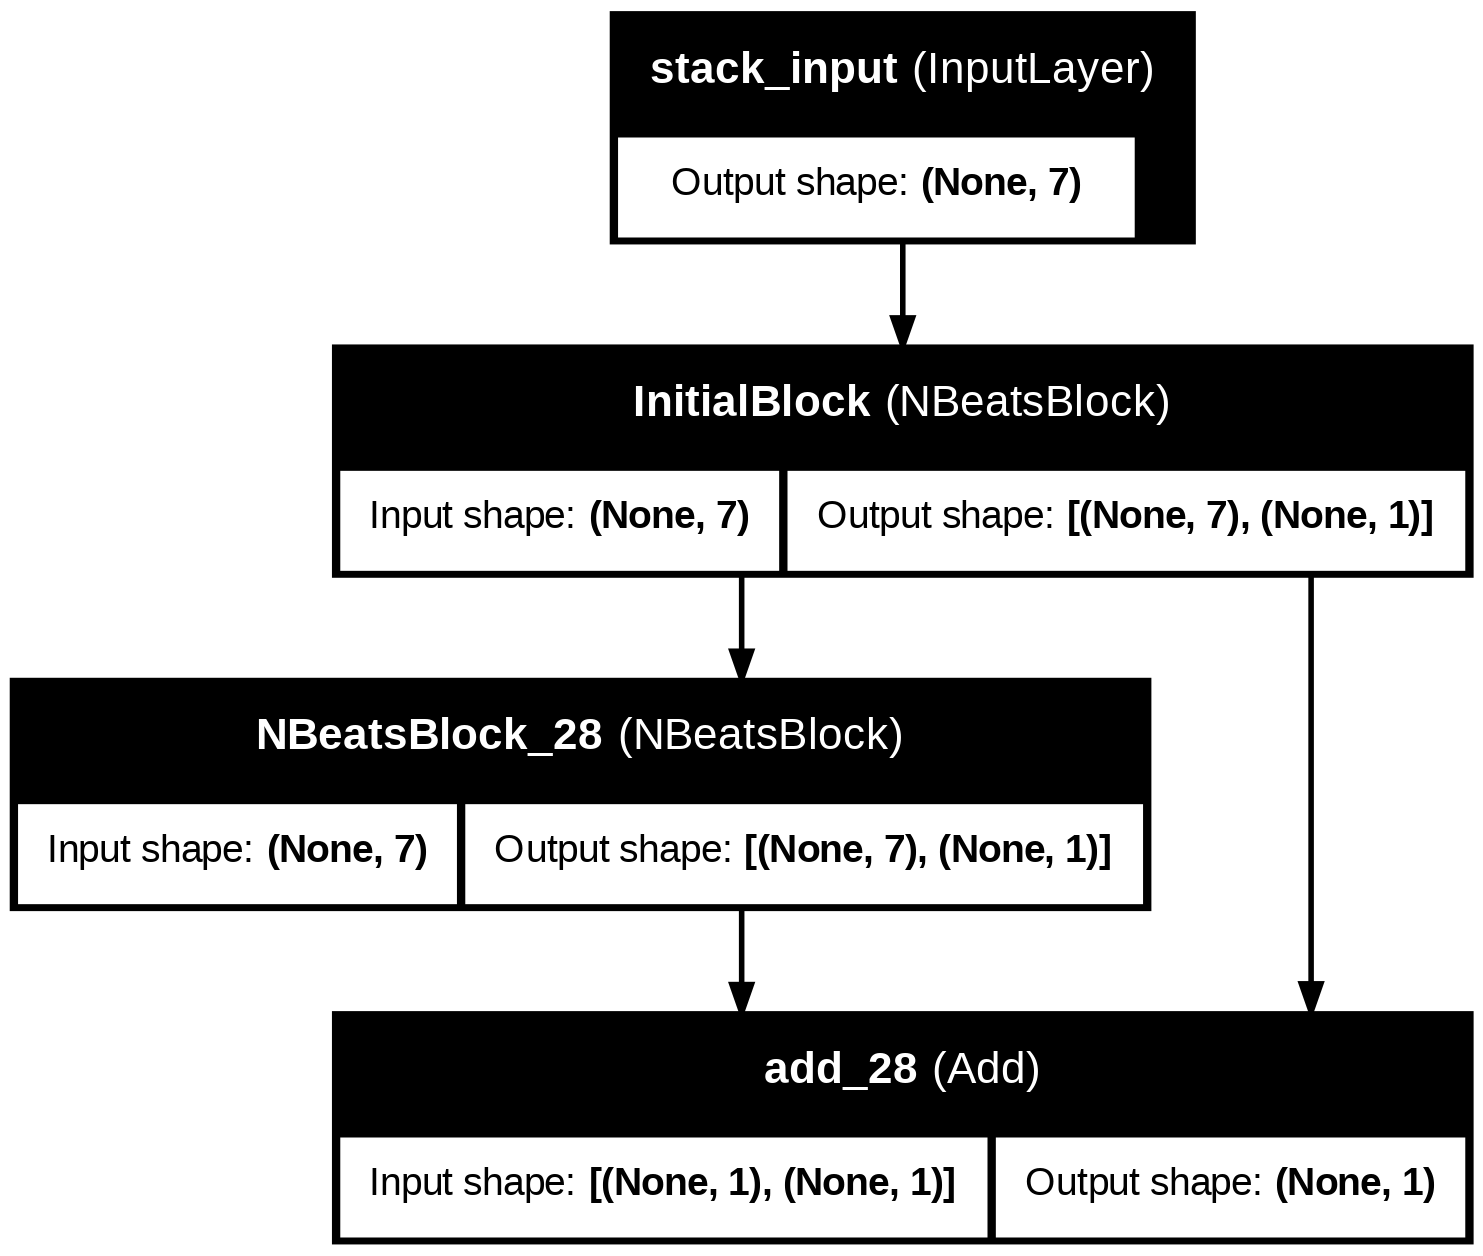

In [129]:
from tensorflow.keras.utils import plot_model
plot_model(model7, show_shapes=True, show_layer_names=True)


## Model 8: Creating an ensemble (stacking different models together)

An ensemble leverages the wisdom of the crowd effect.

It combines many *different* models to predict a common goal.

In [130]:
def get_ensemble_models(horizon=HORIZON,
                        train_data=train_dataset,
                        test_data=test_dataset,
                        num_iter=10,
                        num_epochs=1000,
                        loss_fns=["mae", "mse", "mape"]):
  """
  Returns a list of num_iter models each trained on MAE, MSE and MAPE loss.

  For example, if num_iter=10, a list of 30 trained models will be returned:
  10 * len(["mae", "mse", "mape"]).
  """
  # Make empty list for trained ensemble models
  ensemble_models = []

  # Create num_iter number of models per loss function
  for i in range(num_iter):
    # Build and fit a new model with a different loss function
    for loss_function in loss_fns:
      print(f"Optimizing model by reducing: {loss_function} for {num_epochs} epochs, model number: {i}")

      # Construct a simple model (similar to model_1)
      model = tf.keras.Sequential([
        # Initialize dense layers with normal distribution for estimating prediction intervals later on
        layers.Dense(128, kernel_initializer="he_normal", activation="relu"),
        layers.Dense(128, kernel_initializer="he_normal", activation="relu"),
        layers.Dense(HORIZON)
      ])

      # Compile simple model with current loss function
      model.compile(loss=loss_function,
                    optimizer=tf.keras.optimizers.Adam(),
                    metrics=["mae", "mse"])

      # Fit the current model
      model.fit(train_data,
                epochs=num_epochs,
                verbose=0,
                validation_data=test_data,
                callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss",
                                                            patience=200,
                                                            restore_best_weights=True),
                           tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",
                                                                patience=100,
                                                                verbose=1)])
      # Append fitted model to list of ensemble models
      ensemble_models.append(model)

  return ensemble_models

In [131]:
%%time
# Get list of trained ensemble models
ensemble_models = get_ensemble_models(num_iter=5,
                                      num_epochs=1000)

Optimizing model by reducing: mae for 1000 epochs, model number: 0

Epoch 511: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
Optimizing model by reducing: mse for 1000 epochs, model number: 0

Epoch 436: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 536: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
Optimizing model by reducing: mape for 1000 epochs, model number: 0

Epoch 261: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 937: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
Optimizing model by reducing: mae for 1000 epochs, model number: 1

Epoch 112: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
Optimizing model by reducing: mse for 1000 epochs, model number: 1

Epoch 310: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 410: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
Optimizing model by redu

In [132]:
ensemble_models

[<Sequential name=sequential, built=True>,
 <Sequential name=sequential_1, built=True>,
 <Sequential name=sequential_2, built=True>,
 <Sequential name=sequential_3, built=True>,
 <Sequential name=sequential_4, built=True>,
 <Sequential name=sequential_5, built=True>,
 <Sequential name=sequential_6, built=True>,
 <Sequential name=sequential_7, built=True>,
 <Sequential name=sequential_8, built=True>,
 <Sequential name=sequential_9, built=True>,
 <Sequential name=sequential_10, built=True>,
 <Sequential name=sequential_11, built=True>,
 <Sequential name=sequential_12, built=True>,
 <Sequential name=sequential_13, built=True>,
 <Sequential name=sequential_14, built=True>]

In [133]:
def make_ensemble_preds(ensemble_models, data):
  ensemble_preds = []
  for model in ensemble_models:
    preds = model.predict(data)
    ensemble_preds.append(preds)
  return tf.constant(tf.squeeze(ensemble_preds))

In [134]:
%%time
ensemble_preds = make_ensemble_preds(ensemble_models=ensemble_models,
                                     data=test_dataset)
ensemble_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
CPU times: user 1.78 s, sys: 70.1 ms, total: 1.85 s
Wall time: 1.88 s


<tf.Tensor: shape=(15, 949), dtype=float32, numpy=
array([[ 16566.656,  16532.977,  16435.992, ..., 107067.83 , 107515.336,
        108281.73 ],
       [ 16616.33 ,  16466.373,  16517.617, ..., 107793.664, 106605.47 ,
        108540.46 ],
       [ 16618.242,  16535.666,  16416.498, ..., 106652.42 , 107192.7  ,
        108237.016],
       ...,
       [ 16523.79 ,  16500.232,  16373.957, ..., 106356.77 , 107025.25 ,
        107857.87 ],
       [ 16561.406,  16496.613,  16443.133, ..., 107141.14 , 107383.99 ,
        108374.734],
       [ 16626.96 ,  16491.396,  16438.188, ..., 107066.16 , 107484.44 ,
        108450.016]], dtype=float32)>

In [135]:
ensemble_mean = tf.reduce_mean(ensemble_preds, axis=0)
ensemble_mean[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([16590.459, 16502.41 , 16461.762, 16414.383, 16207.588, 16441.629,
       17158.408, 16974.85 , 17100.057, 16862.701], dtype=float32)>

In [136]:
ensemble_median = np.median(ensemble_preds, axis=0)
ensemble_median[:10]

array([16606.822, 16500.232, 16454.027, 16427.621, 16219.861, 16446.744,
       17154.158, 16979.385, 17106.555, 16865.984], dtype=float32)

In [137]:
ensemble_results = evaluate_preds(y_true=y_test,
                                  y_pred=ensemble_mean)
ensemble_results

{'mae': np.float32(990.22345),
 'mse': np.float32(2424070.2),
 'rmse': np.float32(1556.9426),
 'mape': np.float32(1.7272109),
 'mase': np.float32(0.9976615)}

In [138]:
# Evaluate ensemble model predictions
ensemble_results = evaluate_preds(y_true=y_test,
                                  y_pred=ensemble_median)
ensemble_results

{'mae': np.float32(989.5166),
 'mse': np.float32(2417686.5),
 'rmse': np.float32(1554.8911),
 'mape': np.float32(1.7237233),
 'mase': np.float32(0.9969493)}

In [141]:
bitcoin_prices_windowed


,Price,block_reward,Prince+1,Prince+2,Prince+3,Prince+4,Prince+5,Prince+6,Prince+7
Date,,,,,,,,,
2012-06-30,6.7,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-07-01,6.6,25,6.7,NaN,NaN,NaN,NaN,NaN,NaN
2012-07-02,6.8,25,6.6,6.7,NaN,NaN,NaN,NaN,NaN
2012-07-03,6.4,25,6.8,6.6,6.7,NaN,NaN,NaN,NaN
2012-07-04,6.5,25,6.4,6.8,6.6,6.7,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2025-06-26,106945.9,3.125,107349.4,106078.6,105376.9,100990.4,102113.2,103280.5,104669.6
2025-06-27,107044.2,3.125,106945.9,107349.4,106078.6,105376.9,100990.4,102113.2,103280.5
2025-06-28,107304.4,3.125,107044.2,106945.9,107349.4,106078.6,105376.9,100990.4,102113.2


## Model 9: Train a model on the full historical data to make predictions into the future

So far all of our models have predicted on the test dataset, however, this is only a pseudofuture.

Let's now build a model which is capable of predicting into the future!

In [144]:
X_all=bitcoin_prices_windowed.dropna().drop(["Price","block_reward"],axis=1).to_numpy()
y_all=bitcoin_prices_windowed.dropna()["Price"].to_numpy()
X_all.shape,y_all.shape

((4742, 7), (4742,))

In [145]:

features_dataset_all = tf.data.Dataset.from_tensor_slices(X_all)
labels_dataset_all = tf.data.Dataset.from_tensor_slices(y_all)


dataset_all = tf.data.Dataset.zip((features_dataset_all, labels_dataset_all))


BATCH_SIZE = 1024
dataset_all = dataset_all.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

dataset_all

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 7), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>

In [146]:
tf.random.set_seed(42)

# Create model (nice and simple, just to test)
model_9 = tf.keras.Sequential([
  layers.Dense(128, activation="relu"),
  layers.Dense(128, activation="relu"),
  layers.Dense(HORIZON)
], name="model_9_future_model")

# Compile
model_9.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam())

# Fit model on all of the data to make future forecasts
model_9.fit(dataset_all,
            epochs=100,
            verbose=0)

In [147]:
INTO_FUTURE = 14

In [148]:
tf.expand_dims(y_all[-WINDOW_SIZE:], axis=0)

<tf.Tensor: shape=(1, 7), dtype=float64, numpy=
array([[106078.6, 107349.4, 106945.9, 107044.2, 107304.4, 108361.1,
        107171.1]])>

In [149]:
def make_future_forecasts(values, model, into_future, window_size=WINDOW_SIZE) -> list:
  """
  Make future forecasts into_future steps after values ends.

  Returns future forecasts as a list of floats.
  """
  # 2. Create an empty list for future forecasts/prepare data to forecast on
  future_forecast = []
  last_window = values[-WINDOW_SIZE:]

  # 3. Make INTO_FUTURE numer of predictions, altering the data which gets predicted on each
  for _ in range(INTO_FUTURE):
    # Predict on the last window then append it again, again, again (our model will eventually start to make forecasts on its own forecasts)
    future_pred = model.predict(tf.expand_dims(last_window, axis=0))
    print(f"Predicting on:\n {last_window} -> Prediction: {tf.squeeze(future_pred).numpy()}\n")

    # Append predictions to future_forecast
    future_forecast.append(tf.squeeze(future_pred).numpy())

    # Update last window with new pred and get WINDOW_SIZE most recent preds (model was trained on WINDOW_SIZE windows)
    last_window = np.append(last_window, future_pred)[-WINDOW_SIZE:]

  return future_forecast

In [150]:
future_forecast = make_future_forecasts(values=y_all,
                                        model=model_9,
                                        into_future=INTO_FUTURE,
                                        window_size=WINDOW_SIZE)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
Predicting on:
 [106078.6 107349.4 106945.9 107044.2 107304.4 108361.1 107171.1] -> Prediction: 108143.84375

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicting on:
 [107349.4     106945.9     107044.2     107304.4     108361.1
 107171.1     108143.84375] -> Prediction: 108616.7578125

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicting on:
 [106945.9       107044.2       107304.4       108361.1
 107171.1       108143.84375   108616.7578125] -> Prediction: 108411.1875

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Predicting on:
 [107044.2       107304.4       108361.1       107171.1
 108143.84375   108616.7578125 108411.1875   ] -> Prediction: 108945.9375

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
Predicting on:
 [107304.4       108361.1       107171.1       108143.84375
 108616.7578125 108411.1875    108945.9375   ] -> Prediction: 109058.828125

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Predicting on:
 [108361.1       107171.1       108143.84375   108616.7578125
 1

In [151]:
future_forecast

[np.float32(108143.84),
 np.float32(108616.76),
 np.float32(108411.19),
 np.float32(108945.94),
 np.float32(109058.83),
 np.float32(109374.375),
 np.float32(109264.234),
 np.float32(109806.72),
 np.float32(110087.36),
 np.float32(110174.4),
 np.float32(110580.234),
 np.float32(110673.02),
 np.float32(110905.47),
 np.float32(111101.5)]

In [152]:
def get_future_dates(start_date, into_future, offset=1):
  """
  Returns array of datetime values ranging from start_date to start_date+into_future
  """
  start_date = start_date + np.timedelta64(offset, "D") # specify start date, "D" stands for day
  end_date = start_date + np.timedelta64(into_future, "D") # specify end date
  return np.arange(start_date, end_date, dtype="datetime64[D]")

In [153]:
# Last timestep of timesteps (currently np.datetime64 format)
last_timestep = bitcoin_prices.index[-1]
last_timestep

Timestamp('2025-06-30 00:00:00')

In [154]:
next_time_steps = get_future_dates(start_date=last_timestep,
                                   into_future=INTO_FUTURE)
next_time_steps

array(['2025-07-01', '2025-07-02', '2025-07-03', '2025-07-04',
       '2025-07-05', '2025-07-06', '2025-07-07', '2025-07-08',
       '2025-07-09', '2025-07-10', '2025-07-11', '2025-07-12',
       '2025-07-13', '2025-07-14'], dtype='datetime64[D]')

In [155]:
bitcoin_prices.index

DatetimeIndex(['2012-06-30', '2012-07-01', '2012-07-02', '2012-07-03',
               '2012-07-04', '2012-07-05', '2012-07-06', '2012-07-07',
               '2012-07-08', '2012-07-09',
               ...
               '2025-06-21', '2025-06-22', '2025-06-23', '2025-06-24',
               '2025-06-25', '2025-06-26', '2025-06-27', '2025-06-28',
               '2025-06-29', '2025-06-30'],
              dtype='datetime64[ns]', name='Date', length=4749, freq=None)

In [156]:
next_time_steps = np.insert(next_time_steps, 0, last_timestep)
future_forecast = np.insert(future_forecast, 0, btc_price[-1])
next_time_steps, future_forecast

(array(['2025-06-30', '2025-07-01', '2025-07-02', '2025-07-03',
        '2025-07-04', '2025-07-05', '2025-07-06', '2025-07-07',
        '2025-07-08', '2025-07-09', '2025-07-10', '2025-07-11',
        '2025-07-12', '2025-07-13', '2025-07-14'], dtype='datetime64[D]'),
 array([107171.1  , 108143.84 , 108616.76 , 108411.19 , 108945.94 ,
        109058.83 , 109374.375, 109264.234, 109806.72 , 110087.36 ,
        110174.4  , 110580.234, 110673.02 , 110905.47 , 111101.5  ],
       dtype=float32))

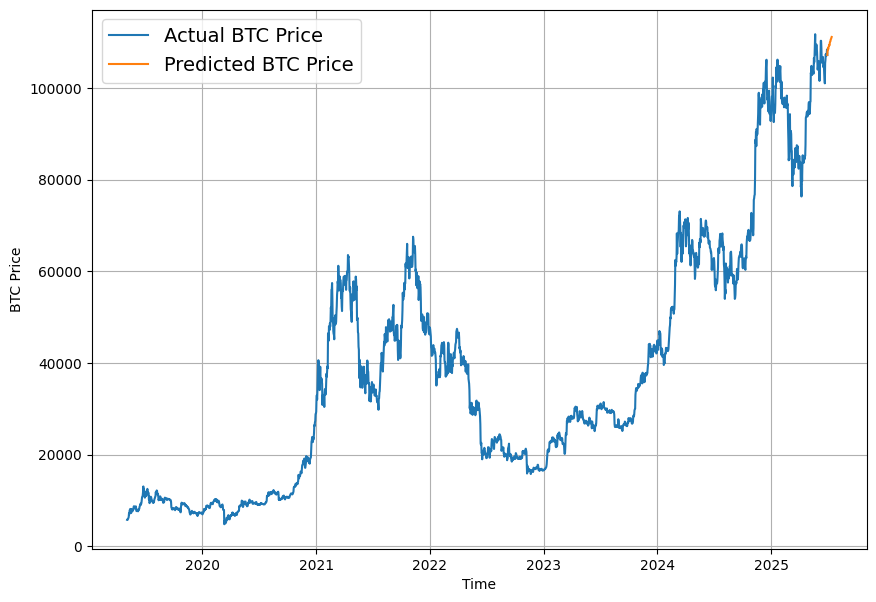

In [158]:
plt.figure(figsize=(10, 7))
plot_time_series(bitcoin_prices.index, btc_price, start=2500, format="-", label="Actual BTC Price")
plot_time_series(next_time_steps, future_forecast, format="-", label="Predicted BTC Price")

## Model 10: Why forecasting is BS (the turkey problem 🦃)


In [159]:
# Let's introduce a turkey prolbme to our BTC data (price of BTC falls 100x in one day)
btc_price_turkey = btc_price.copy()
btc_price_turkey[-1] = btc_price_turkey[-1] / 100

In [160]:
# Manufacture an extra price on the end (to showcase our Turkey problem)
btc_price_turkey[-10:]

[102113.2,
 100990.4,
 105376.9,
 106078.6,
 107349.4,
 106945.9,
 107044.2,
 107304.4,
 108361.1,
 1071.711]

In [161]:
# Get the timesteps for the turkey problem
btc_timesteps_turkey = np.array(bitcoin_prices.index)
btc_timesteps_turkey[-10:]

array(['2025-06-21T00:00:00.000000000', '2025-06-22T00:00:00.000000000',
       '2025-06-23T00:00:00.000000000', '2025-06-24T00:00:00.000000000',
       '2025-06-25T00:00:00.000000000', '2025-06-26T00:00:00.000000000',
       '2025-06-27T00:00:00.000000000', '2025-06-28T00:00:00.000000000',
       '2025-06-29T00:00:00.000000000', '2025-06-30T00:00:00.000000000'],
      dtype='datetime64[ns]')

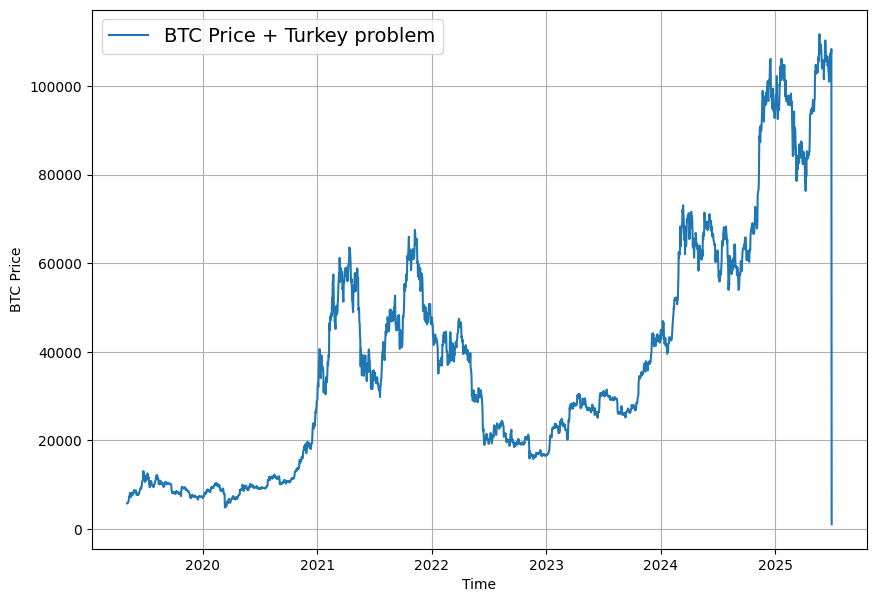

In [162]:
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=btc_timesteps_turkey,
                 values=btc_price_turkey,
                 format="-",
                 label="BTC Price + Turkey problem",
                 start=2500
                 )

In [163]:
HORIZON = 1
WINDOW_SIZE = 7

In [177]:
full_windows, full_labels = make_windows(np.array(btc_price_turkey), window_size=WINDOW_SIZE, horizon=HORIZON)

X_train, X_test, y_train, y_test = make_train_test_splits(full_windows, full_labels)
len(X_train), len(X_test), len(y_train), len(y_test)

Train size: 3793, Test size: 949


(3793, 949, 3793, 949)

In [178]:
WINDOW_SIZE

7

In [179]:
HORIZON

1

In [180]:
# Clone model 1 architecture for turkey model and fit the turkey model on the turkey data
turkey_model=tf.keras.Sequential([
    layers.Dense(128,activation="relu"),
    layers.Dense(HORIZON,activation="linear")
],name="model10_turkey_model")

turkey_model.compile(loss="mae",
                     optimizer=tf.keras.optimizers.Adam())

turkey_model.fit(X_train, y_train,
                 epochs=100,
                 verbose=0,
                 batch_size=128,
                 validation_data=(X_test, y_test),
                 callbacks=[create_model_checkpoint(turkey_model.name+".keras")])

In [181]:
turkey_model.evaluate(X_test, y_test)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 613.1688


1098.6351318359375

In [182]:
turkey_model = tf.keras.models.load_model("/content/model_experiment/model10_turkey_model.keras")
turkey_model.evaluate(X_test, y_test)

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 612.3699


1097.642333984375

In [183]:
turkey_preds = make_preds(turkey_model, X_test)
turkey_preds[:10]

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([16618.896, 16526.41 , 16474.705, 16447.385, 16244.636, 16429.162,
       17110.895, 17009.402, 17097.143, 16915.236], dtype=float32)>

In [184]:
turkey_results = evaluate_preds(y_true=y_test,
                                y_pred=turkey_preds)
turkey_results

{'mae': np.float32(32082.477),
 'mse': np.float32(1598003000.0),
 'rmse': np.float32(39975.027),
 'mape': np.float32(81.70491),
 'mase': np.float32(29.048012)}

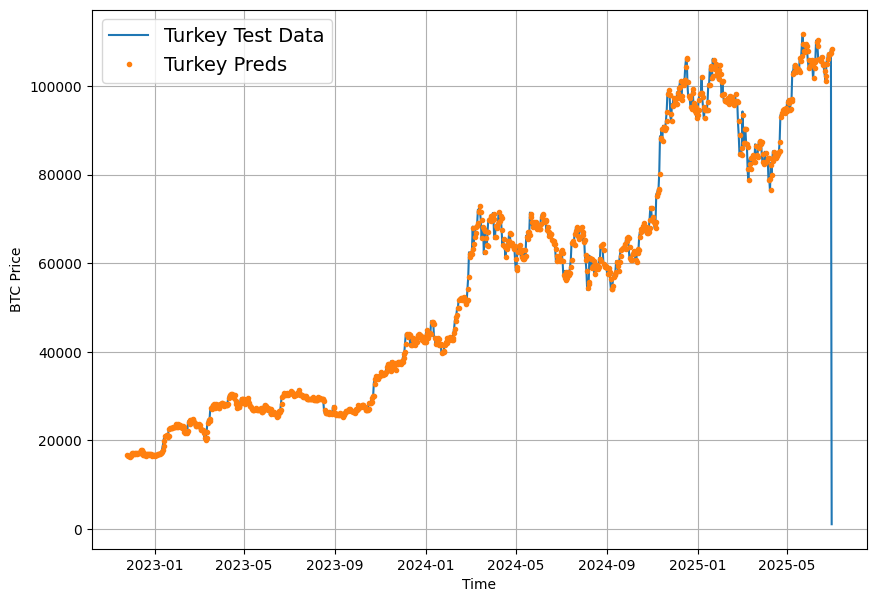

In [185]:
plt.figure(figsize=(10, 7))
offset=0
plot_time_series(timesteps=btc_timesteps_turkey[-len(X_test):],
                 values=btc_price_turkey[-len(y_test):],
                 format="-",
                 label="Turkey Test Data",
                 start=offset)
plot_time_series(timesteps=btc_timesteps_turkey[-len(X_test):],
                 values=turkey_preds,
                 label="Turkey Preds",
                 start=offset);


## Compare models

In [186]:
model_results = pd.DataFrame({"naive_model": navie_results,
                              "model_1_dense_w7_h1": model1_results,
                              "model_2_dense_w30_h1": model2_results,
                              "model_3_dense_w30_h7": model3_results,
                              "model_4_CONV1D": model4_results,
                              "model_5_LSTM": model5_results,
                              "model_6_multivariate": model6_results,
                              "model_7_NBEATS": model7_results,
                              "model_8_ensemble": ensemble_results,
                              "model_10_turkey": turkey_results}).T
model_results.head(10)

,mae,mse,rmse,mape,mase
naive_model,991.592346,2.445224e+06,1563.721191,1.726922,0.999041
model_1_dense_w7_h1,55449.230469,3.873351e+09,62236.250000,792131.937500,NaN
model_2_dense_w30_h1,55445.281250,3.864236e+09,62162.972656,792075.312500,NaN
model_3_dense_w30_h7,2095.259033,9.514717e+06,3084.593506,3.774671,2.103868
model_4_CONV1D,2552.805908,1.292892e+07,3595.681396,4.634390,2.563294
model_5_LSTM,2530.044678,1.299349e+07,3604.647949,4.614465,2.540439
model_6_multivariate,998.527832,2.457639e+06,1567.685791,1.739234,1.006028
model_7_NBEATS,981.537415,2.412479e+06,1553.215576,1.711048,0.988910
model_8_ensemble,989.516602,2.417686e+06,1554.891113,1.723723,0.996949
model_10_turkey,32082.476562,1.598003e+09,39975.027344,81.704910,29.048012


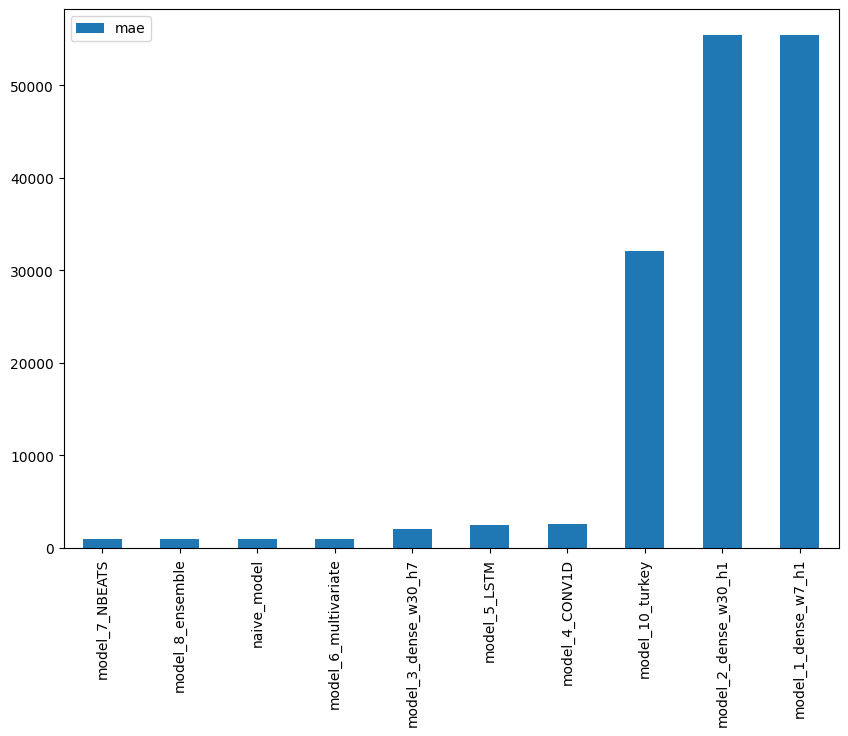

In [187]:
model_results[["mae"]].sort_values(by="mae").plot(figsize=(10, 7), kind="bar");